In [1]:
import numpy as np
import pandas as pd
from utils import *
from models.double_bind_model import DoubleBindModel
from models.single_therapy_model import SingleTherapyModel
from models.combination_model import CombinationModel

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid", {"grid.color": ".6", "grid.linestyle": ":"})

from copy import deepcopy

import warnings
warnings.filterwarnings("ignore")


# Base case

## Global parameters


In [2]:
growth_rate = 0.28

maximum_carrying_capacity = 100
maximum_carrying_capacity_std = 10

strategy_max_efficacy = 0
cost_of_evolvability = 0.127

baseline_heterogeneity = 0.025 ## Same as baseline evolvability for fixed evo models


### Chemo Parameters

efficacy_chemo = 0.17
efficacy_chemo_std = np.sqrt(6)  ## Treatment Generality


### Targeted

efficacy_targeted = 0.30
efficacy_targeted_std = np.sqrt(2)  ## Treatment Generality

### Evolvability

LOW_EVOLVABILITY = 0.2
HIGH_EVOLVABILITY = 0.35

cycle = 50 #cycle duration
cov = 0.015 #covariance

### Graphing Parameters

targeted_color = "#dc143c"
chemo_color = "#6A5ACD"
double_bind_color = "#9932CC"


try:
    display
except NameError:
    def display(value):
        print(value.to_string(index=False))


def display_parameter_table(case_name, plot_name, parameters, extra_parameters=None):
    displayed = dict(parameters)
    if extra_parameters:
        displayed.update(extra_parameters)
    print(f"{case_name}: {plot_name}")
    display(pd.DataFrame({"Parameter": displayed.keys(), "Value": displayed.values()}))


def show_parameters(
    plot_name,
    extra_parameters=None,
    include_facultative_scaling=False,
    include_half_dose_scaling=False,
):
    parameters = {
        "growth rate (r)": growth_rate,
        "evolvability cost (d)": cost_of_evolvability,
        "maximum carrying capacity (K_m)": maximum_carrying_capacity,
        "carrying-capacity breadth (sigma_k)": maximum_carrying_capacity_std,
        "baseline evolvability (m)": baseline_heterogeneity,
        "low fixed evolvability": LOW_EVOLVABILITY,
        "high/plastic evolvability ceiling": HIGH_EVOLVABILITY,
        "chemotherapy efficacy (s_c)": efficacy_chemo,
        "chemotherapy breadth (sigma_sc)": efficacy_chemo_std,
        "targeted efficacy (s_t)": efficacy_targeted,
        "targeted breadth (sigma_st)": efficacy_targeted_std,
        "covariance magnitude (delta)": cov,
    }

    if include_facultative_scaling:
        parameters.update({
            "facultative scaling factor (f_c)": (
                HIGH_EVOLVABILITY - baseline_heterogeneity
            ) / efficacy_chemo,
            "facultative scaling factor (f_t)": (
                HIGH_EVOLVABILITY - baseline_heterogeneity
            ) / efficacy_targeted,
        })

    if include_half_dose_scaling:
        parameters.update({
            "half-dose facultative scaling factor (f_c)": (
                HIGH_EVOLVABILITY - baseline_heterogeneity
            ) / (efficacy_chemo / 2),
            "half-dose facultative scaling factor (f_t)": (
                HIGH_EVOLVABILITY - baseline_heterogeneity
            ) / (efficacy_targeted / 2),
        })

    display_parameter_table(
        "Non-alternative case",
        plot_name,
        parameters,
        extra_parameters,
    )


## Adaptive Landscape

Non-alternative case: Adaptive landscape


,Parameter,Value
0,growth rate (r),0.280000
1,evolvability cost (d),0.127000
2,maximum carrying capacity (K_m),100.000000
3,carrying-capacity breadth (sigma_k),10.000000
4,baseline evolvability (m),0.025000
5,low fixed evolvability,0.200000
6,high/plastic evolvability ceiling,0.350000
7,chemotherapy efficacy (s_c),0.170000
8,chemotherapy breadth (sigma_sc),2.449490
9,targeted efficacy (s_t),0.300000


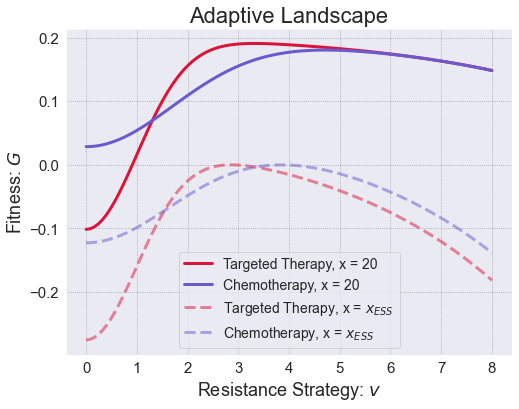

Maximum G_chemo (x=20) = 0.1805 at v = 4.6869
Maximum G_targeted (x=20) = 0.1909 at v = 3.3131
Maximum G_chemo (x=ESS) = -0.0000 at v = 3.8788
Maximum G_targeted (x=ESS) = 0.0001 at v = 2.8283


In [40]:
show_parameters("Adaptive landscape")

linewidth = 3
label_font = 20
font_title = 22
font_axis = 18
font_legend = 14
font_ticks = 15

v_vals = np.linspace(0, 8, 100)

G_chemo = G_function(v_vals, 20, growth_rate, maximum_carrying_capacity, maximum_carrying_capacity_std,
                     efficacy_chemo, strategy_max_efficacy, efficacy_chemo_std,
                     cost_of_evolvability, LOW_EVOLVABILITY)

G_targeted = G_function(v_vals, 20, growth_rate, maximum_carrying_capacity, maximum_carrying_capacity_std,
                        efficacy_targeted, strategy_max_efficacy, efficacy_targeted_std,
                        cost_of_evolvability, LOW_EVOLVABILITY)

G_chemo_ESS = G_function(v_vals, 73.98, growth_rate, maximum_carrying_capacity, maximum_carrying_capacity_std,
                     efficacy_chemo, strategy_max_efficacy, efficacy_chemo_std,
                     cost_of_evolvability, LOW_EVOLVABILITY)

G_targeted_ESS = G_function(v_vals, 82.10, growth_rate, maximum_carrying_capacity, maximum_carrying_capacity_std,
                        efficacy_targeted, strategy_max_efficacy, efficacy_targeted_std,
                        cost_of_evolvability, LOW_EVOLVABILITY)



plt.figure(figsize=(8, 6))
plt.plot(v_vals, G_targeted, label="Targeted Therapy, x = 20", color=targeted_color, linewidth = linewidth)
plt.plot(v_vals, G_chemo, label="Chemotherapy, x = 20", color=chemo_color, linewidth = linewidth)

plt.plot(v_vals, G_targeted_ESS, label="Targeted Therapy, x = $x_{ESS}$", color=targeted_color, linewidth = linewidth, linestyle = '--', alpha = 0.5)
plt.plot(v_vals, G_chemo_ESS, label="Chemotherapy, x = $x_{ESS}$", color=chemo_color, linewidth = linewidth, linestyle = '--', alpha = 0.5)
plt.legend(fontsize = font_legend)

plt.tick_params(labelsize=font_ticks)

plt.title("Adaptive Landscape", fontsize = font_title)
plt.xlabel("Resistance Strategy: $v$", fontsize = font_axis)
plt.ylabel("Fitness: $G$", fontsize = font_axis)
plt.grid(True)
plt.show()



def find_max_info(G_vals, v_vals, label):
    idx = np.argmax(G_vals)
    print(f"Maximum {label} = {G_vals[idx]:.4f} at v = {v_vals[idx]:.4f}")

find_max_info(G_chemo, v_vals, "G_chemo (x=20)")
find_max_info(G_targeted, v_vals, "G_targeted (x=20)")
find_max_info(G_chemo_ESS, v_vals, "G_chemo (x=ESS)")
find_max_info(G_targeted_ESS, v_vals, "G_targeted (x=ESS)")


## Constant Evolvability Panels

In [41]:
## Fixed Evo Models

init = [20, 0.01]

low_evo_constant_model_chemo = SingleTherapyModel(
    init = init,
    #t_max = 5000,

    growth_rate = growth_rate,
    carrying_capacity_std = maximum_carrying_capacity_std,
    evolvability_cost = cost_of_evolvability,

    
    
    
    efficacy=efficacy_chemo,
    efficacy_std=efficacy_chemo_std,
    evolvability_value = LOW_EVOLVABILITY,

    facultative_evolvability=False,
    intermittent = False
)

#low_evo_constant_model_chemo.get_scaling_factor(HIGH_EVOLVABILITY)
low_evo_constant_model_chemo.run()
low_evo_constant_model_chemo.apply_extinction()

low_evo_constant_model_targeted = SingleTherapyModel(
    init = init,
    #t_max = 5000,

    growth_rate = growth_rate,
    carrying_capacity_std = maximum_carrying_capacity_std,
    evolvability_cost = cost_of_evolvability,
    
    efficacy=efficacy_targeted,
    efficacy_std=efficacy_targeted_std,
    evolvability_value = LOW_EVOLVABILITY,

    facultative_evolvability=False,
    intermittent = False
)

#low_evo_constant_model_targeted.get_scaling_factor(HIGH_EVOLVABILITY)
low_evo_constant_model_targeted.run()
low_evo_constant_model_targeted.apply_extinction()

high_evo_constant_model_chemo = SingleTherapyModel(
    init = init,
    #t_max = 5000,

    growth_rate = growth_rate,
    carrying_capacity_std = maximum_carrying_capacity_std,
    evolvability_cost = cost_of_evolvability,

    efficacy=efficacy_chemo,
    efficacy_std=efficacy_chemo_std,
    evolvability_value = HIGH_EVOLVABILITY,

    facultative_evolvability=False,
    intermittent = False
)

#high_evo_constant_model_chemo.get_scaling_factor(HIGH_EVOLVABILITY)
high_evo_constant_model_chemo.run()
high_evo_constant_model_chemo.apply_extinction()

high_evo_constant_model_targeted = SingleTherapyModel(
    init = init,

    growth_rate = growth_rate,
    carrying_capacity_std = maximum_carrying_capacity_std,
    evolvability_cost = cost_of_evolvability,

    
    efficacy=efficacy_targeted,
    efficacy_std=efficacy_targeted_std,
    evolvability_value = HIGH_EVOLVABILITY,

    facultative_evolvability=False,
    intermittent = False
)

for model in [high_evo_constant_model_chemo, high_evo_constant_model_targeted, low_evo_constant_model_chemo, low_evo_constant_model_targeted]:

    model.run()
    model.apply_extinction()



Non-alternative case: Continuous therapy - fixed evolvability


,Parameter,Value
0,growth rate (r),0.280000
1,evolvability cost (d),0.127000
2,maximum carrying capacity (K_m),100.000000
3,carrying-capacity breadth (sigma_k),10.000000
4,baseline evolvability (m),0.025000
5,low fixed evolvability,0.200000
6,high/plastic evolvability ceiling,0.350000
7,chemotherapy efficacy (s_c),0.170000
8,chemotherapy breadth (sigma_sc),2.449490
9,targeted efficacy (s_t),0.300000


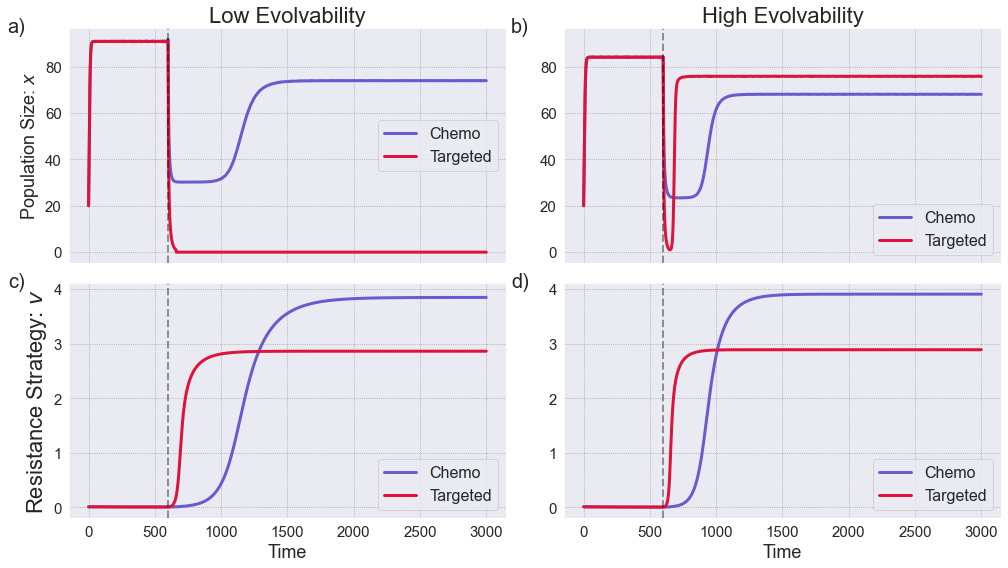

84.18689746276192 90.77757906728172
84.18689746276192 90.77757906728172
68.11534357171763 73.98865697703403
75.79124892419642 0.0


In [44]:
show_parameters("Continuous therapy - fixed evolvability")

## Make plots

linewidth = 3
label_font = 20
font_title = 22
font_axis = 18
font_legend = 16
font_ticks = 15

panel_labels = ['a)', 'b)', 'c)', 'd)']
label_positions = [(-0.1, 1.05), (-0.08, 1.05),  # top row
                   (-0.1, 1.05), (-0.08, 1.05)]  # bottom row

fig, ax = plt.subplots(2, 2, figsize=(14, 8), sharex=True)



# === Top Left: Low Evolvability - Population ===
ax[0, 0].set_title("Low Evolvability", fontsize = font_title)
#ax[0, 0].set_ylim(0, 100)
ax[0, 0].plot(low_evo_constant_model_chemo.t, low_evo_constant_model_chemo.y[0], color=chemo_color, linewidth=linewidth, label="Chemo")
ax[0, 0].plot(low_evo_constant_model_targeted.t, low_evo_constant_model_targeted.y[0], color=targeted_color, linewidth=linewidth, label="Targeted")
ax[0, 0].set_ylabel("Population Size: $x$", fontsize = font_axis)

# === Bottom Left: Low Evolvability - Strategy ===
#ax[1, 1].set_title("Low Evolvability - Strategy")
ax[1, 0].set_xlabel("Time", fontsize = font_axis)
ax[1, 0].plot(low_evo_constant_model_chemo.t, low_evo_constant_model_chemo.y[1], color=chemo_color, linewidth=linewidth, label="Chemo")
ax[1, 0].plot(low_evo_constant_model_targeted.t, low_evo_constant_model_targeted.y[1], color=targeted_color, linewidth=linewidth, label="Targeted")
ax[1, 0].set_ylabel("Resistance Strategy: $v$", fontsize = font_title)

# === Top Right: High Evolvability - Population ===
ax[0, 1].set_title("High Evolvability", fontsize = font_title)

#ax[0, 1].set_ylim(0, 100)
ax[0, 1].plot(high_evo_constant_model_chemo.t, high_evo_constant_model_chemo.y[0], color=chemo_color, linewidth=linewidth, label="Chemo")
ax[0, 1].plot(high_evo_constant_model_targeted.t, high_evo_constant_model_targeted.y[0], color=targeted_color, linewidth=linewidth, label="Targeted")

# === Bottom Right: High Evolvability - Strategy ===
#ax[1, 0].set_title("High Evolvability - Strategy")

ax[1, 1].set_xlabel("Time", fontsize = font_axis)
ax[1, 1].plot(high_evo_constant_model_chemo.t, high_evo_constant_model_chemo.y[1], color=chemo_color, linewidth=linewidth, label="Chemo")
ax[1, 1].plot(high_evo_constant_model_targeted.t, high_evo_constant_model_targeted.y[1], color=targeted_color, linewidth=linewidth, label="Targeted")

# === Final polish ===
for i, axes in enumerate(ax.flat):
    axes.axvline(x=high_evo_constant_model_chemo.therapy_start_time, color='black',
                 linestyle='--', linewidth=2, alpha=0.4)
    axes.tick_params(labelsize=font_ticks)
    axes.legend(fontsize=font_legend)

    x_pos, y_pos = label_positions[i]
    axes.text(x_pos, y_pos, panel_labels[i], transform=axes.transAxes,
              fontsize=label_font, va='top', ha='right')
    
    
#repeat_legend(ax)
match_ylim_by_row(ax)


plt.tight_layout()
plt.show()


print(high_evo_constant_model_chemo.y[0][500], low_evo_constant_model_chemo.y[0][500])
print(high_evo_constant_model_targeted.y[0][500], low_evo_constant_model_targeted.y[0][500])
print(high_evo_constant_model_chemo.y[0][-1], low_evo_constant_model_chemo.y[0][-1])
print(high_evo_constant_model_targeted.y[0][-1], low_evo_constant_model_targeted.y[0][-1])



## Facultative Panels

In [6]:
facultative_model_chemo = SingleTherapyModel(
    init = init,

    growth_rate = growth_rate,
    carrying_capacity_std = maximum_carrying_capacity_std,
    evolvability_cost = cost_of_evolvability,

    efficacy=efficacy_chemo,
    efficacy_std=efficacy_chemo_std,
    evolvability_value = baseline_heterogeneity,

    facultative_evolvability=True,
    intermittent = False
)




facultative_model_targeted = SingleTherapyModel(
    init = init,

    growth_rate = growth_rate,
    carrying_capacity_std = maximum_carrying_capacity_std,
    evolvability_cost = cost_of_evolvability,

    efficacy=efficacy_targeted,
    efficacy_std=efficacy_targeted_std,
    evolvability_value = baseline_heterogeneity,

    facultative_evolvability=True,
    intermittent = False
)


for model in [facultative_model_chemo, facultative_model_targeted]:
    model.get_evolvability_scaling_factor(HIGH_EVOLVABILITY)
    print(model.evolvability_scaling_factor)
    model.run()
    model.apply_extinction()



1.9117647058823526
1.0833333333333333


Non-alternative case: Continuous therapy - fixed and plastic evolvability


,Parameter,Value
0,growth rate (r),0.280000
1,evolvability cost (d),0.127000
2,maximum carrying capacity (K_m),100.000000
3,carrying-capacity breadth (sigma_k),10.000000
4,baseline evolvability (m),0.025000
5,low fixed evolvability,0.200000
6,high/plastic evolvability ceiling,0.350000
7,chemotherapy efficacy (s_c),0.170000
8,chemotherapy breadth (sigma_sc),2.449490
9,targeted efficacy (s_t),0.300000


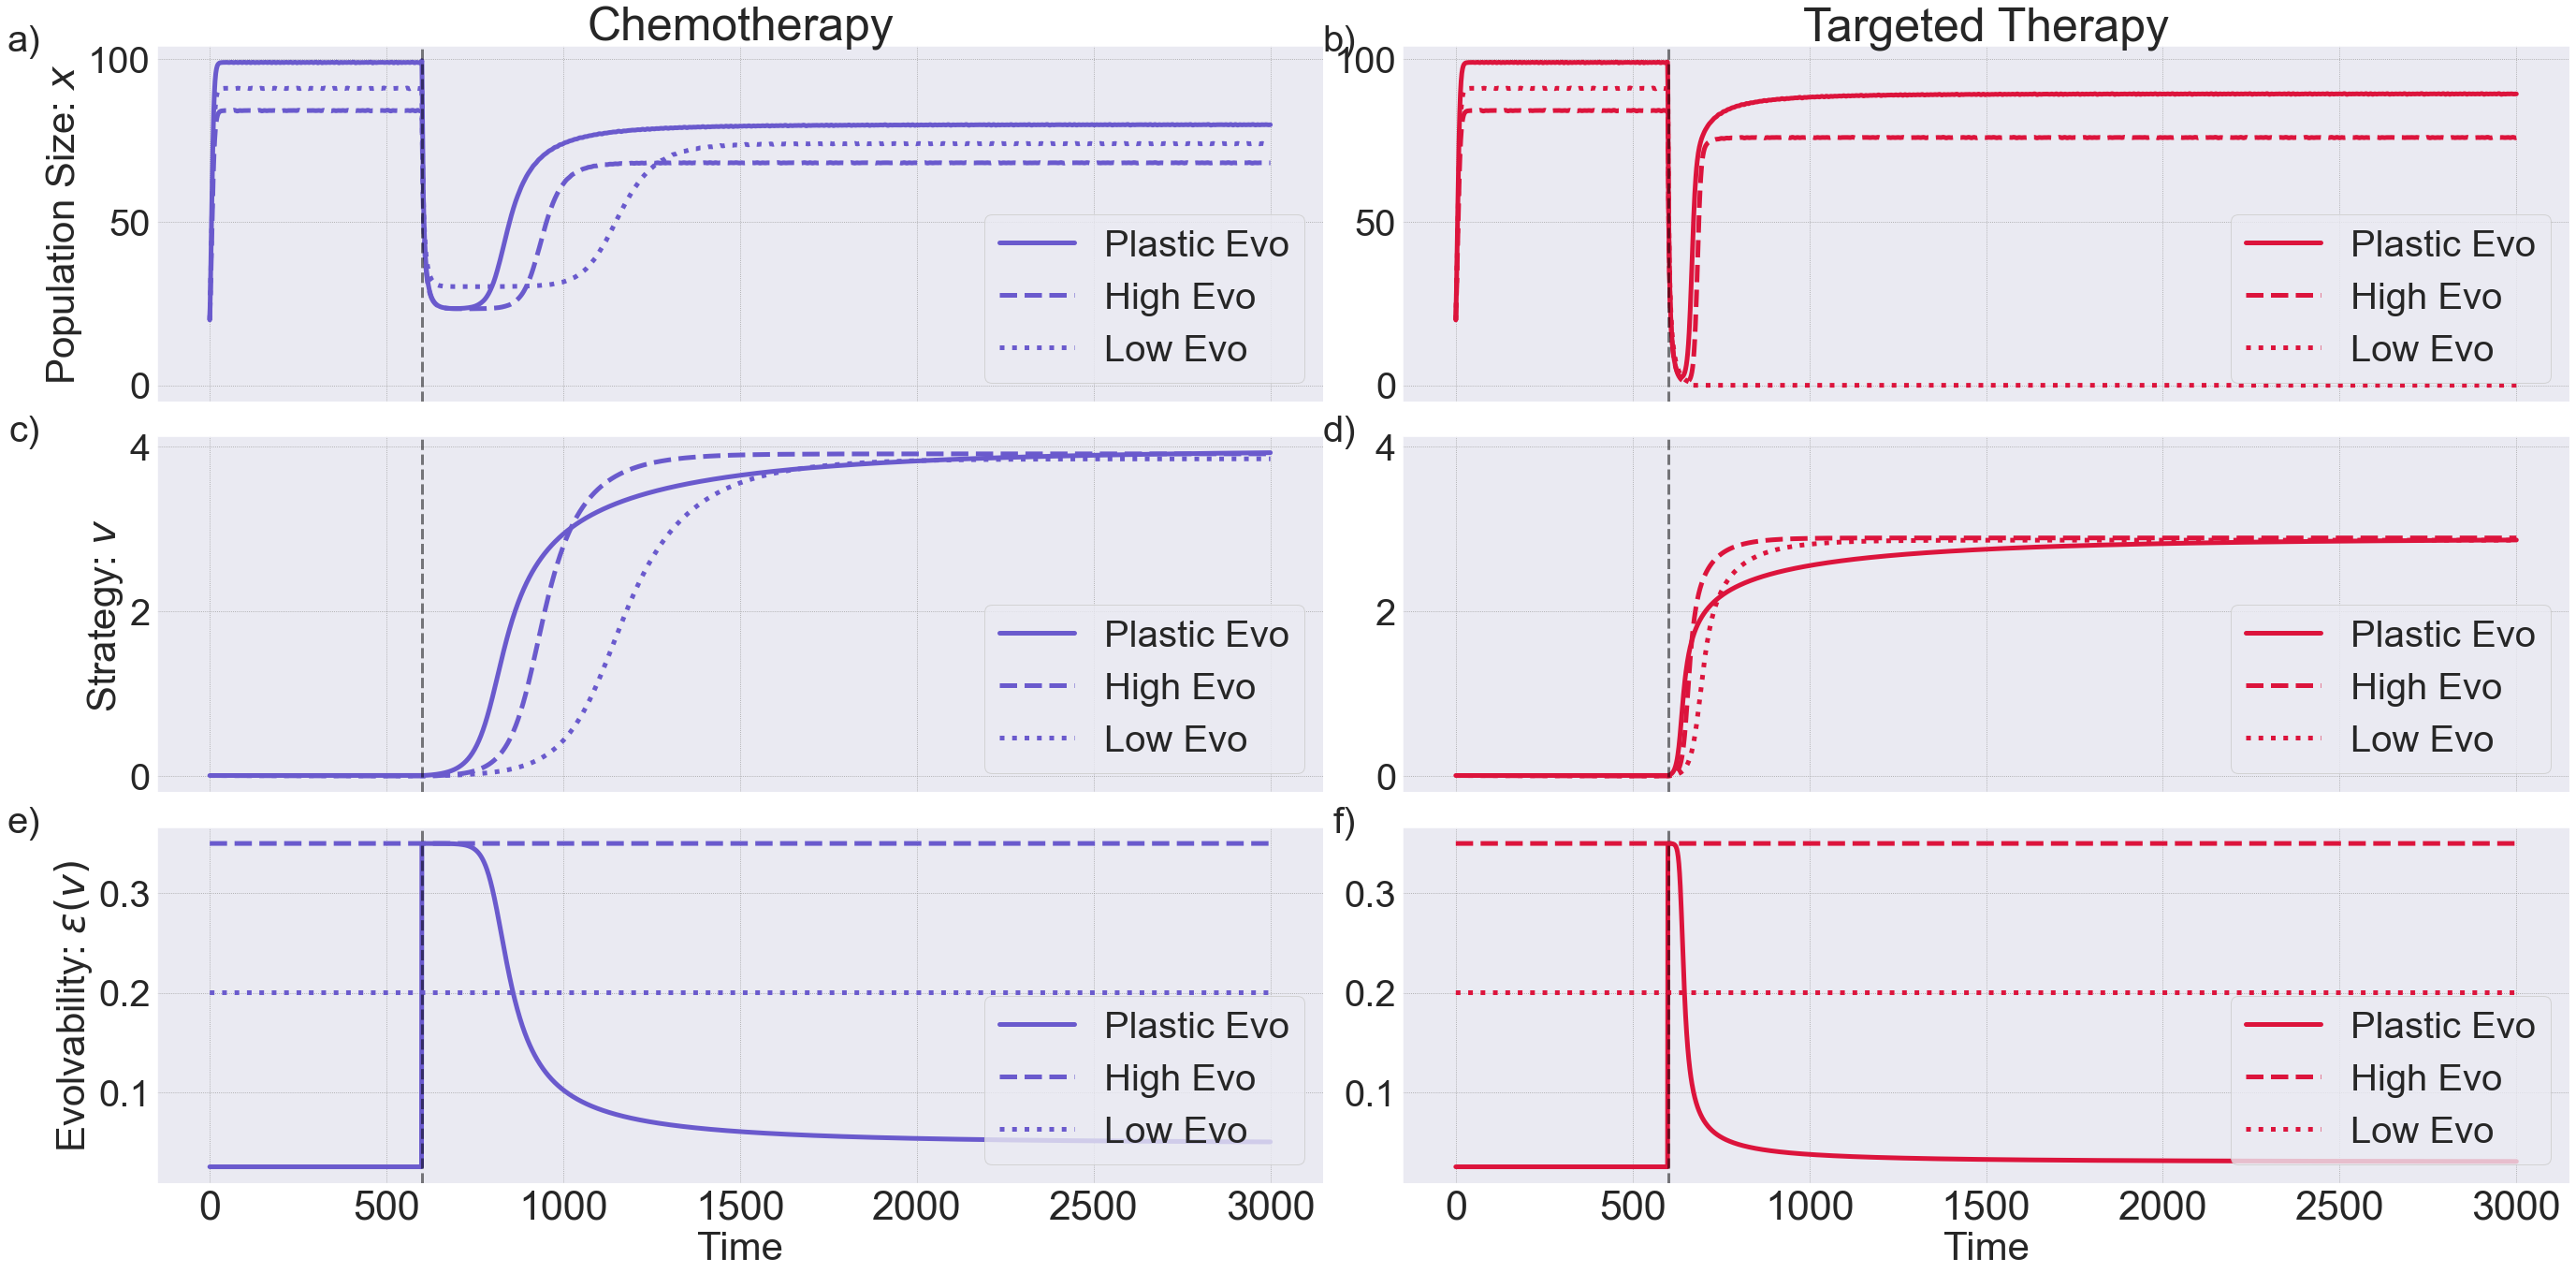

98.92476427886075 98.92476427886075
79.77334482194486 89.21369005369476


In [45]:
show_parameters("Continuous therapy - fixed and plastic evolvability", include_facultative_scaling=True)

linewidth = 5
label_font = 40        # font for subplot labels (a), (b), etc.
font_title = 50        # font for subplot titles
font_axis = 42         # font for axis labels
font_legend = 40       # font for legend
font_ticks_y = 40      # font for y-axis tick labels
font_ticks_x = 43      # font for x-axis tick labels


panel_labels = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)']
label_positions = [(-0.10, 1.06),  # (a) top-left
                   (-0.04, 1.06),  # (b) top-right
                   (-0.10, 1.06),  # (c) mid-left
                   (-0.04, 1.06),  # (d) mid-right
                   (-0.10, 1.06),  # (e) bottom-left
                   (-0.04, 1.06)]  # (f) bottom-right

fig, ax = plt.subplots(3, 2, figsize=(38, 19), sharex=True)

# === Top Left: Facultative Evolvability - Population (Chemo) ===
ax[0, 0].set_title("Chemotherapy", fontsize = font_title) 
ax[0, 0].plot(facultative_model_chemo.t, facultative_model_chemo.y[0], color=chemo_color, linewidth=linewidth, label="Plastic Evo")
ax[0, 0].plot(high_evo_constant_model_chemo.t, high_evo_constant_model_chemo.y[0], color=chemo_color, linestyle='--', linewidth=linewidth, label="High Evo")
ax[0, 0].plot(low_evo_constant_model_chemo.t, low_evo_constant_model_chemo.y[0], color=chemo_color, linestyle=':', linewidth=linewidth, label="Low Evo")
ax[0, 0].set_ylabel("Population Size: $x$", fontsize = font_axis)
ax[0, 0].legend()

# === Middle Left: Facultative Evolvability - Strategy (Chemo)===
#ax[1, 0].set_title("Chemotherapy - Strategy")
ax[1, 0].plot(facultative_model_chemo.t, facultative_model_chemo.y[1], color=chemo_color, linewidth=linewidth, label="Plastic Evo")
ax[1, 0].plot(high_evo_constant_model_chemo.t, high_evo_constant_model_chemo.y[1], color=chemo_color, linestyle='--', linewidth=linewidth, label="High Evo")  
ax[1, 0].plot(low_evo_constant_model_chemo.t, low_evo_constant_model_chemo.y[1], color=chemo_color, linestyle=':', linewidth=linewidth, label="Low Evo")
ax[1, 0].set_ylabel("Strategy: $v$", fontsize = font_axis)
ax[1, 0].legend()


# === Bottom Left: Evolvability ===
#ax[2, 0].set_title("Chemotherapy - Evolvability")
ax[2, 0].plot(facultative_model_chemo.t, facultative_model_chemo.evo, color=chemo_color, linewidth=linewidth, label="Plastic Evo")
ax[2, 0].plot(high_evo_constant_model_chemo.t, high_evo_constant_model_chemo.evo, color=chemo_color, linestyle='--', linewidth=linewidth, label="High Evo")
ax[2, 0].plot(low_evo_constant_model_chemo.t, low_evo_constant_model_chemo.evo, color=chemo_color, linestyle=':', linewidth=linewidth, label="Low Evo")
ax[2, 0].set_ylabel("Evolvability: $\epsilon(v)$", fontsize = font_axis)
ax[2, 0].set_xlabel("Time", fontsize = font_axis)
ax[2, 0].legend()

# === Top Right: Facultative Evolvability - Population (Targeted) ===
ax[0, 1].set_title("Targeted Therapy", fontsize = font_title)
ax[0, 1].plot(facultative_model_targeted.t, facultative_model_targeted.y[0], color=targeted_color, linewidth=linewidth, label="Plastic Evo")
ax[0, 1].plot(high_evo_constant_model_targeted.t, high_evo_constant_model_targeted.y[0], color=targeted_color, linestyle='--', linewidth=linewidth, label="High Evo")
ax[0, 1].plot(low_evo_constant_model_targeted.t, low_evo_constant_model_targeted.y[0], color=targeted_color, linestyle=':', linewidth=linewidth, label="Low Evo")
#ax[0, 1].set_ylabel("Population Size: $x$", fontsize = font_axis)
ax[0, 1].legend()

# === Middle Right: Facultative Evolvability - Strategy (Targeted) ===
#ax[1, 1].set_title("Targeted Therapy - Strategy")
ax[1, 1].plot(facultative_model_targeted.t, facultative_model_targeted.y[1], color=targeted_color, linewidth=linewidth, label="Plastic Evo")
ax[1, 1].plot(high_evo_constant_model_targeted.t, high_evo_constant_model_targeted.y[1], color=targeted_color, linestyle='--', linewidth=linewidth, label="High Evo")
ax[1, 1].plot(low_evo_constant_model_targeted.t, low_evo_constant_model_targeted.y[1], color=targeted_color, linestyle=':', linewidth=linewidth, label="Low Evo")
#ax[1, 1].set_ylabel("Strategy: $v$", fontsize = font_axis)
ax[1, 1].legend()

# === Bottom Right: Evolvability (Targeted) ===
#ax[2, 1].set_title("Targeted Therapy - Evolvability")
ax[2, 1].plot(facultative_model_targeted.t, facultative_model_targeted.evo, color=targeted_color, linewidth=linewidth, label="Plastic Evo")
ax[2, 1].plot(high_evo_constant_model_targeted.t, high_evo_constant_model_targeted.evo, color=targeted_color, linestyle='--', linewidth=linewidth, label="High Evo")
ax[2, 1].plot(low_evo_constant_model_targeted.t, low_evo_constant_model_targeted.evo, color=targeted_color, linestyle=':', linewidth=linewidth, label="Low Evo")
ax[2, 1].set_xlabel("Time", fontsize = font_axis)
#ax[2, 1].set_ylabel("Evolvability: $\epsilon(v)$", fontsize = font_axis)


for i, axes in enumerate(ax.flat):
    axes.axvline(x=high_evo_constant_model_chemo.therapy_start_time, color='black',
                 linestyle='--', linewidth=3, alpha=0.5)
    axes.tick_params(axis='x', labelsize=font_ticks_x)
    axes.tick_params(axis='y', labelsize=font_ticks_y)

    axes.legend(fontsize=font_legend, loc = "lower right")

    x_pos, y_pos = label_positions[i]
    axes.text(x_pos, y_pos, panel_labels[i], transform=axes.transAxes,
              fontsize=label_font, va='top', ha='right')

#repeat_legend(ax)
match_ylim_by_row(ax)

plt.tight_layout()
plt.show()

print(facultative_model_chemo.y[0][500], facultative_model_targeted.y[0][500])
print(facultative_model_chemo.y[0][-1], facultative_model_targeted.y[0][-1])


## Intermittent Therapy

In [8]:
t_max = 5000
init = [20, 0.01]

# Facultative model
facultative_intermittent_chemo = SingleTherapyModel(
    init=init,
    t_max=t_max,
    growth_rate=growth_rate,
    carrying_capacity_std = maximum_carrying_capacity_std,
    evolvability_cost = cost_of_evolvability,

    
    efficacy=efficacy_chemo,
    efficacy_std=efficacy_chemo_std,
    evolvability_value=baseline_heterogeneity,
    facultative_evolvability=True,
    intermittent=True,
    cycle_duration = cycle
)


# Low constant evolvability model
low_evo_intermittent_chemo = SingleTherapyModel(
    init=init,
    t_max=t_max,
    growth_rate=growth_rate,
    carrying_capacity_std = maximum_carrying_capacity_std,
    evolvability_cost = cost_of_evolvability,

    
    efficacy=efficacy_chemo,
    efficacy_std=efficacy_chemo_std,
    evolvability_value=LOW_EVOLVABILITY,
    facultative_evolvability=False,
    intermittent=True,
    cycle_duration = cycle
)


# High constant evolvability model
high_evo_intermittent_chemo = SingleTherapyModel(
    init=init,
    t_max=t_max,
    growth_rate=growth_rate,
    carrying_capacity_std = maximum_carrying_capacity_std,
    evolvability_cost = cost_of_evolvability,

    
    efficacy=efficacy_chemo,
    efficacy_std=efficacy_chemo_std,
    evolvability_value=HIGH_EVOLVABILITY,
    facultative_evolvability=False,
    intermittent=True,
    cycle_duration = cycle
)

for model in [high_evo_intermittent_chemo, low_evo_intermittent_chemo, facultative_intermittent_chemo]:
    model.get_evolvability_scaling_factor(HIGH_EVOLVABILITY)
    model.run()
    model.apply_extinction()


Non-alternative case: Intermittent chemotherapy


,Parameter,Value
0,growth rate (r),0.280000
1,evolvability cost (d),0.127000
2,maximum carrying capacity (K_m),100.000000
3,carrying-capacity breadth (sigma_k),10.000000
4,baseline evolvability (m),0.025000
5,low fixed evolvability,0.200000
6,high/plastic evolvability ceiling,0.350000
7,chemotherapy efficacy (s_c),0.170000
8,chemotherapy breadth (sigma_sc),2.449490
9,targeted efficacy (s_t),0.300000


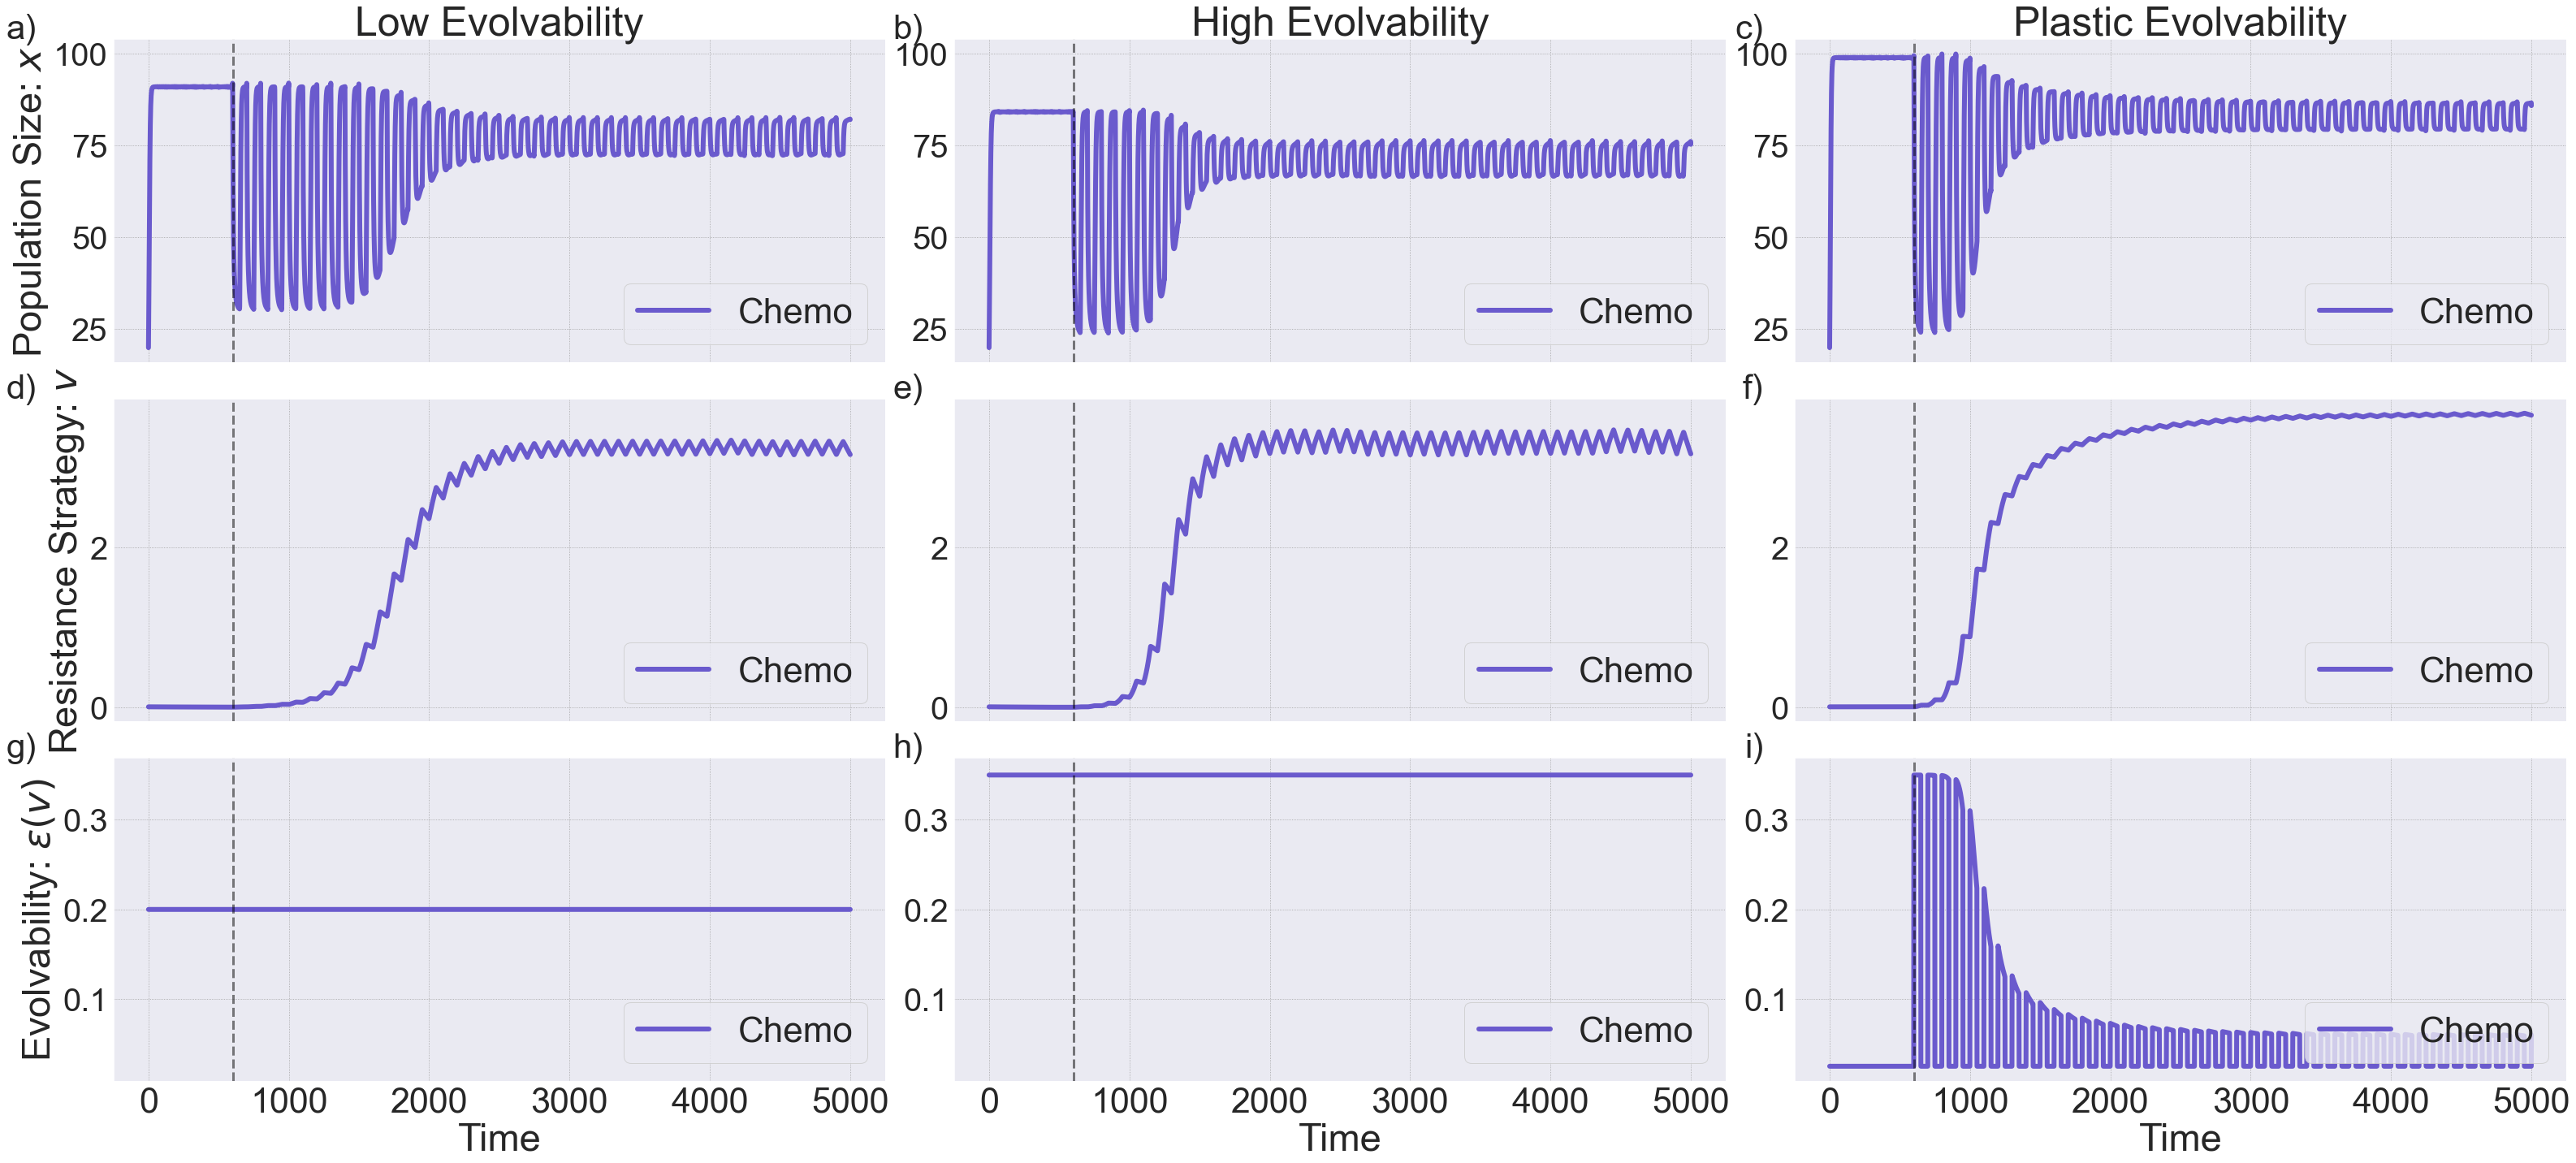

66.51453945911717 76.33242236863616
72.36394424628335 82.57668364289096
78.9823026055136 87.12674267255521


In [58]:
show_parameters("Intermittent chemotherapy", {"cycle duration": 50}, include_facultative_scaling=True)

linewidth = 6
label_font = 42        # font for subplot labels (a), (b), etc.
font_title = 50        # font for subplot titles
font_axis = 47        # font for axis labels
font_legend = 44       # font for legend
font_ticks_y = 40      # font for y-axis tick labels
font_ticks_x = 43      # font for x-axis tick labels

panel_labels = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)', 'g)', 'h)', 'i)']
label_positions = [(-0.10, 1.08),  # (a) top-left
                   (-0.04, 1.08),  # (b) top-mid
                   (-0.04, 1.08),  # (c) top-right
                   (-0.10, 1.08),  # (d) mid-left
                   (-0.04, 1.08),  # (e) mid-mid
                   (-0.04, 1.08),  # (f) mid-right
                   (-0.10, 1.08),  # (g) bottom-left
                   (-0.04, 1.08),  # (h) bottom-mid
                    (-0.04, 1.08)]  # (h) bottom-right

fig, ax = plt.subplots(3, 3, figsize=(44, 20), sharex=True)

# Each model to be displayed in a column
models = [
    ("Low Evolvability", low_evo_intermittent_chemo),
    ("High Evolvability", high_evo_intermittent_chemo),
    ("Plastic Evolvability", facultative_intermittent_chemo),
]

# Row 0: Population
for j, (label, model) in enumerate(models):
    ax[0, j].plot(model.t, model.y[0], color=chemo_color, linewidth=linewidth, label="Chemo")
    ax[0, j].set_title(f"{label}", fontsize = font_title)
    ax[0, j].legend(loc="lower right")
    

# Row 1: Strategy
for j, (label, model) in enumerate(models):
    ax[1, j].plot(model.t, model.y[1], color=chemo_color, linewidth=linewidth, label="Chemo")
    #ax[1, j].set_title(f"{label} - Strategy")
    #ax[1, j].set_xlabel("Time", fontsize = font_axis)
    ax[1, j].legend(loc="lower right")

# Row 2: Evolvability
for j, (label, model) in enumerate(models):
    ax[2, j].plot(model.t, model.evo, color=chemo_color, linewidth=linewidth, label="Chemo")
    #ax[2, j].set_title(f"{label} - Evolvability")
    ax[2, j].set_xlabel("Time", fontsize = font_axis)
    ax[2, j].legend(loc="lower right")

# Add y-axis labels only on left column
ax[0, 0].set_ylabel("Population Size: $x$", fontsize = font_axis)
ax[1, 0].set_ylabel("Resistance Strategy: $v$", fontsize = font_axis)
ax[2, 0].set_ylabel("Evolvability: $\epsilon(v)$", fontsize = font_axis)

# Unify y-limits per row
match_ylim_by_row(ax)

# Final polish
for i, axes in enumerate(ax.flat):
    axes.axvline(x=high_evo_constant_model_chemo.therapy_start_time, color='black',
                 linestyle='--', linewidth=3, alpha=0.5)
    axes.tick_params(axis='x', labelsize=font_ticks_x)
    axes.tick_params(axis='y', labelsize=font_ticks_y)

    axes.legend(fontsize=font_legend, loc = "lower right")

    x_pos, y_pos = label_positions[i]
    axes.text(x_pos, y_pos, panel_labels[i], transform=axes.transAxes,
              fontsize=label_font, va='top', ha='right')
    
plt.tight_layout()
plt.show()

# print(np.min(high_evo_intermittent_chemo.y[0]), np.min(low_evo_intermittent_chemo.y[0]), np.min(facultative_intermittent_chemo.y[0]))
print(np.min(high_evo_intermittent_chemo.y[0][3000:3500]), np.max(high_evo_intermittent_chemo.y[0][3000:3500]))
print(np.min(low_evo_intermittent_chemo.y[0][3000:3500]), np.max(low_evo_intermittent_chemo.y[0][3000:3500]))
print(np.min(facultative_intermittent_chemo.y[0][3000:3500]), np.max(facultative_intermittent_chemo.y[0][3000:3500]))
# print(facultative_intermittent_chemo.y[0][3000:3100])


In [10]:
facultative_intermittent_targeted = SingleTherapyModel(
    init=init,
    t_max=t_max,
    growth_rate=growth_rate,
    carrying_capacity_std = maximum_carrying_capacity_std,
    evolvability_cost = cost_of_evolvability,

    
    efficacy=efficacy_targeted,
    efficacy_std=efficacy_targeted_std,
    evolvability_value=baseline_heterogeneity,
    facultative_evolvability=True,
    intermittent=True,
    cycle_duration = cycle
)

# Low constant evolvability
low_evo_intermittent_targeted = SingleTherapyModel(
    init=init,
    t_max=t_max,
    growth_rate=growth_rate,
    carrying_capacity_std = maximum_carrying_capacity_std,
    evolvability_cost = cost_of_evolvability,

    
    efficacy=efficacy_targeted,
    efficacy_std=efficacy_targeted_std,
    evolvability_value=LOW_EVOLVABILITY,
    facultative_evolvability=False,
    intermittent=True,
    cycle_duration = cycle
)

# High constant evolvability
high_evo_intermittent_targeted = SingleTherapyModel(
    init=init,
    t_max=t_max,
    growth_rate=growth_rate,
    carrying_capacity_std = maximum_carrying_capacity_std,
    evolvability_cost = cost_of_evolvability,

    
    efficacy=efficacy_targeted,
    efficacy_std=efficacy_targeted_std,
    evolvability_value=HIGH_EVOLVABILITY,
    facultative_evolvability=False,
    intermittent=True,
    cycle_duration = cycle
)

for model in [high_evo_intermittent_targeted, low_evo_intermittent_targeted, facultative_intermittent_targeted]:
    model.get_evolvability_scaling_factor(HIGH_EVOLVABILITY)
    model.run()
    model.apply_extinction()


Non-alternative case: Intermittent targeted therapy


,Parameter,Value
0,growth rate (r),0.280000
1,evolvability cost (d),0.127000
2,maximum carrying capacity (K_m),100.000000
3,carrying-capacity breadth (sigma_k),10.000000
4,baseline evolvability (m),0.025000
5,low fixed evolvability,0.200000
6,high/plastic evolvability ceiling,0.350000
7,chemotherapy efficacy (s_c),0.170000
8,chemotherapy breadth (sigma_sc),2.449490
9,targeted efficacy (s_t),0.300000


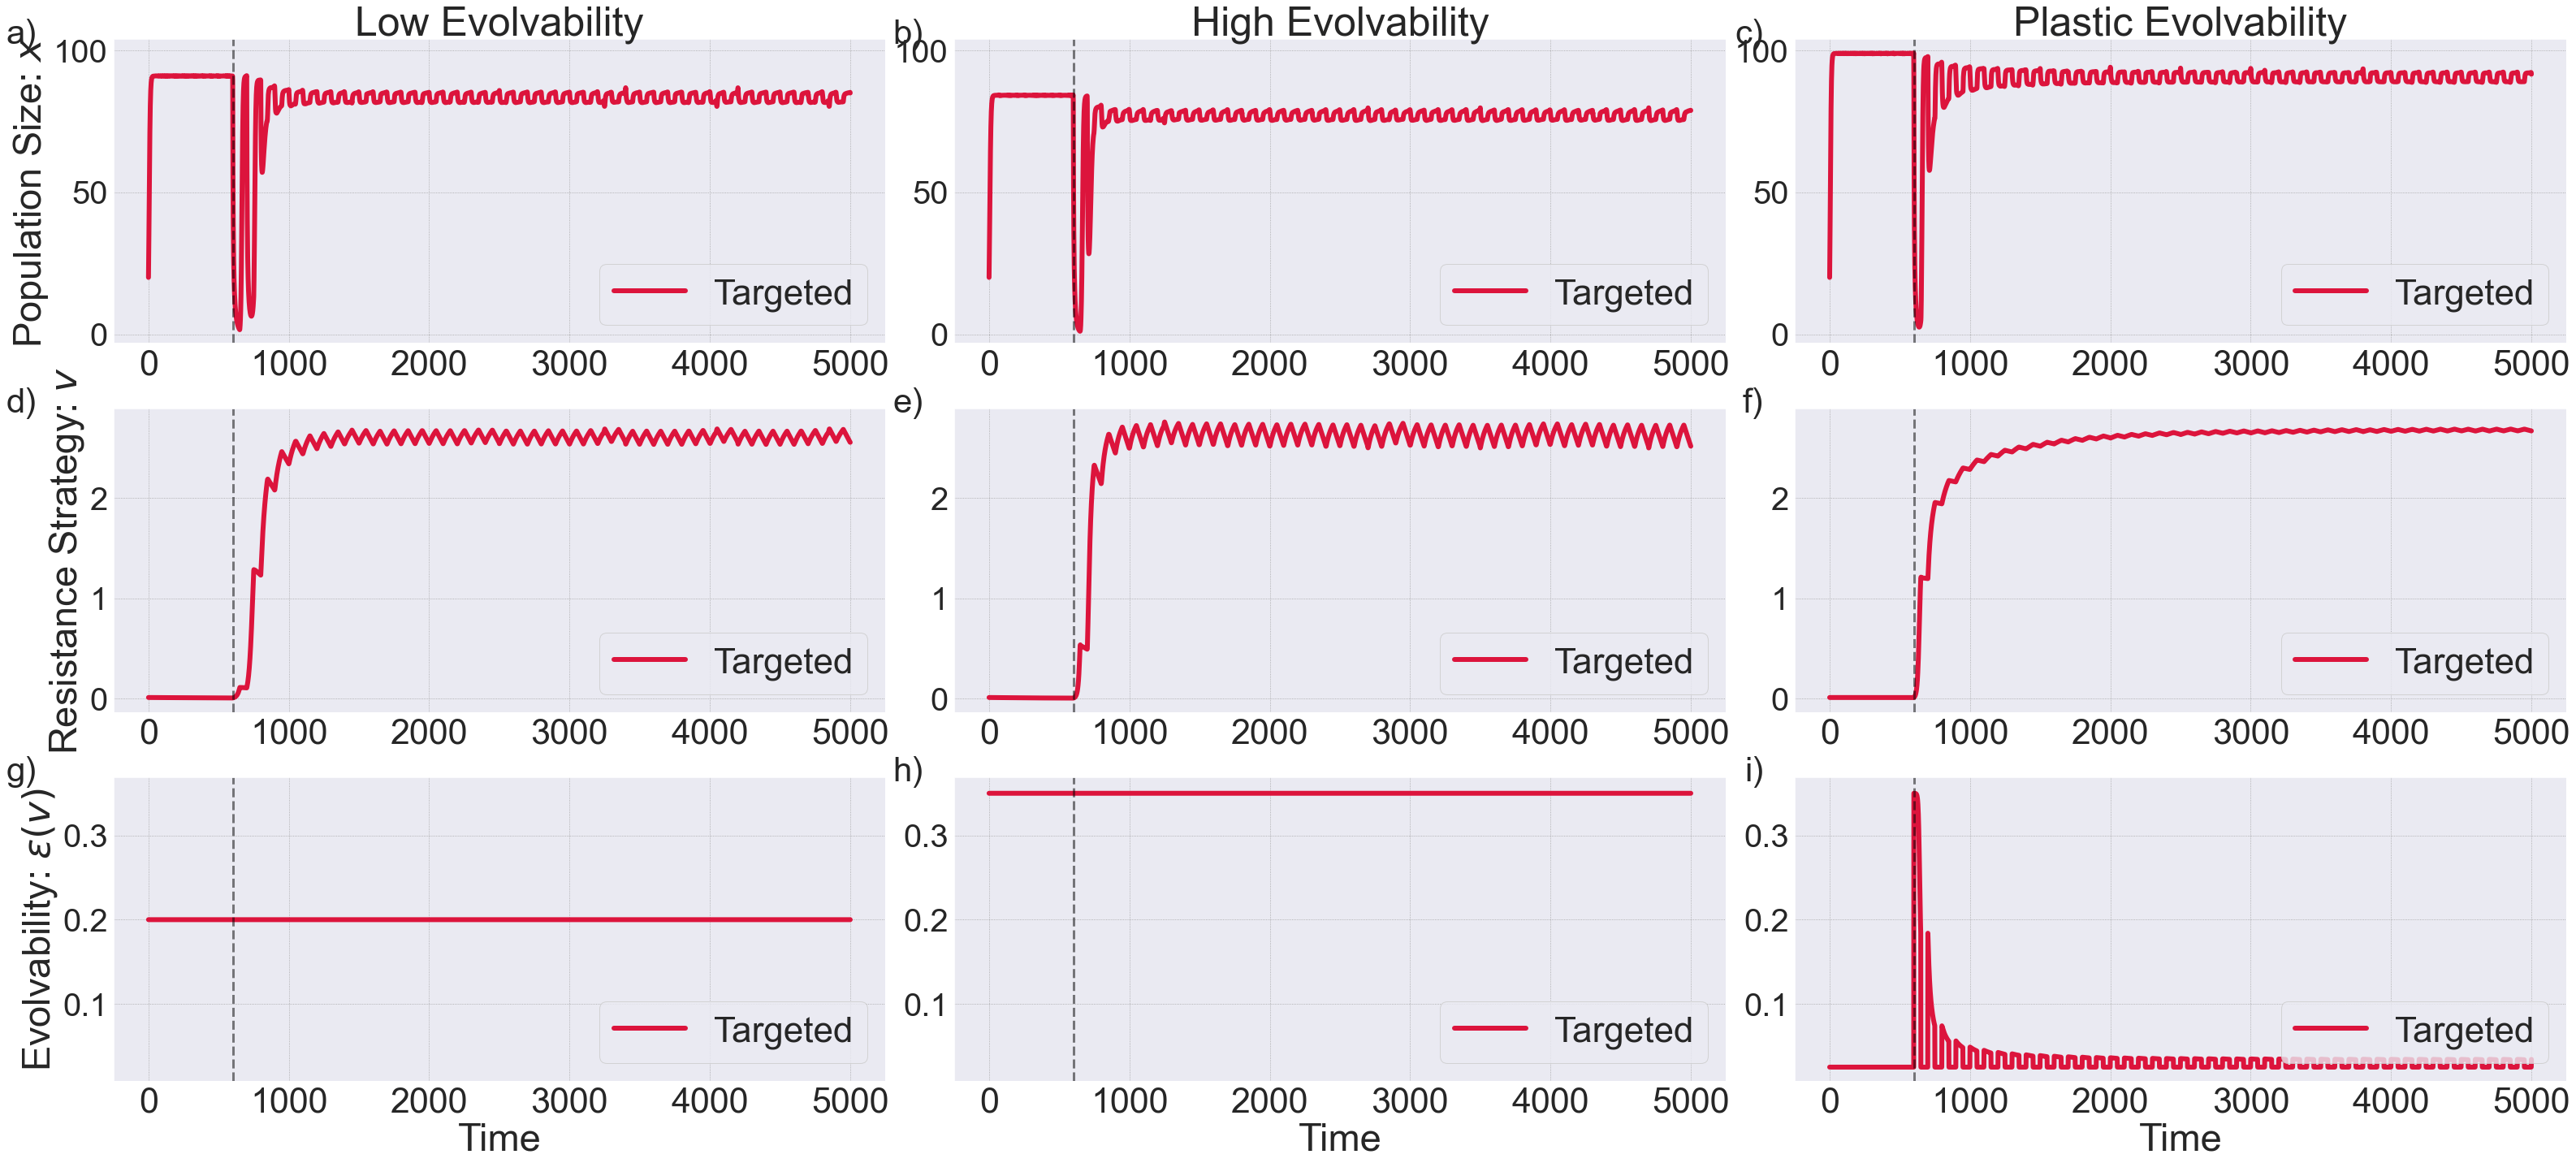

75.26151623501234 79.10800133755924
80.23272165265095 86.78115777011848
88.57945283955057 93.59313069634754


In [57]:
show_parameters("Intermittent targeted therapy", {"cycle duration": 50}, include_facultative_scaling=True)

linewidth = 6
label_font = 42        # font for subplot labels (a), (b), etc.
font_title = 50        # font for subplot titles
font_axis = 47        # font for axis labels
font_legend = 44       # font for legend
font_ticks_y = 40      # font for y-axis tick labels
font_ticks_x = 43      # font for x-axis tick labels


panel_labels = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)', 'g)', 'h)', 'i)']
label_positions = [(-0.10, 1.07),  # (a) top-left
                   (-0.04, 1.07),  # (b) top-mid
                   (-0.04, 1.07),  # (c) top-right
                   (-0.10, 1.07),  # (d) mid-left
                   (-0.04, 1.07),  # (e) mid-mid
                   (-0.04, 1.07),  # (f) mid-right
                   (-0.10, 1.07),  # (g) bottom-left
                   (-0.04, 1.07),  # (h) bottom-mid
                    (-0.04, 1.07)]  # (h) bottom-right

fig, ax = plt.subplots(3, 3, figsize=(44, 20), sharex=True)

models = [
    ("Low Evolvability", low_evo_intermittent_targeted),
    ("High Evolvability", high_evo_intermittent_targeted),
    ("Plastic Evolvability", facultative_intermittent_targeted),
]

# Row 0: Population
for j, (label, model) in enumerate(models):
    ax[0, j].plot(model.t, model.y[0], color=targeted_color, linewidth=linewidth, label="Targeted")
    ax[0, j].set_title(f"{label}", fontsize = font_title)
    ax[0, j].legend(loc="lower right")
    
# Row 1: Strategy
for j, (label, model) in enumerate(models):
    ax[1, j].plot(model.t, model.y[1], color=targeted_color, linewidth=linewidth, label="Targeted")
    ax[1, j].legend(loc="lower right")

# Row 2: Evolvability
for j, (label, model) in enumerate(models):
    ax[2, j].plot(model.t, model.evo, color=targeted_color, linewidth=linewidth, label="Targeted")
    ax[2, j].set_xlabel("Time", fontsize = font_axis)
    ax[2, j].legend(loc="lower right")

match_ylim_by_row(ax)
repeat_legend(ax)

# Y-axis labels
ax[0, 0].set_ylabel("Population Size: $x$", fontsize = font_axis)
ax[1, 0].set_ylabel("Resistance Strategy: $v$", fontsize = font_axis)
ax[2, 0].set_ylabel("Evolvability: $\epsilon(v)$", fontsize = font_axis)


# Final polish
for i, axes in enumerate(ax.flat):
    axes.axvline(x=high_evo_constant_model_chemo.therapy_start_time, color='black',
                 linestyle='--', linewidth=3, alpha=0.5)
    axes.tick_params(axis='x', labelsize=font_ticks_x)
    axes.tick_params(axis='y', labelsize=font_ticks_y)

    axes.legend(fontsize=font_legend, loc = "lower right")

    x_pos, y_pos = label_positions[i]
    axes.text(x_pos, y_pos, panel_labels[i], transform=axes.transAxes,
              fontsize=label_font, va='top', ha='right')
    
plt.tight_layout()
plt.show()

#print(np.min(high_evo_intermittent_targeted.y[0]), np.min(low_evo_intermittent_targeted.y[0]), np.min(facultative_intermittent_targeted.y[0]))
print(np.min(high_evo_intermittent_targeted.y[0][3000:3500]), np.max(high_evo_intermittent_targeted.y[0][3000:3500]))
print(np.min(low_evo_intermittent_targeted.y[0][3000:3500]), np.max(low_evo_intermittent_targeted.y[0][3000:3500]))
print(np.min(facultative_intermittent_targeted.y[0][3000:3500]), np.max(facultative_intermittent_targeted.y[0][3000:3500]))
#print(low_evo_intermittent_targeted.y[0][2000:2500])
#print(facultative_intermittent_targeted.y[0][2000:2500])


## Double Bind

### Double bind with Short cycle_duration

In [60]:
init = [20, 0.01, 0.01]
t_max = 5000

# Facultative
double_bind_facultative = DoubleBindModel(
    init=init,
    t_max=t_max,
    growth_rate=growth_rate,
    carrying_capacity_std=maximum_carrying_capacity_std,
    efficacy_1=efficacy_chemo,
    efficacy_2=efficacy_targeted,
    efficacy_std_1=efficacy_chemo_std,
    efficacy_std_2=efficacy_targeted_std,
    evolvability_value=baseline_heterogeneity,
    facultative_evolvability=True,
    cycle_duration = cycle,
    covariance=cov
)


# Low evolvability
double_bind_low = DoubleBindModel(
    init=init,
    t_max=t_max,
    growth_rate=growth_rate,
    carrying_capacity_std=maximum_carrying_capacity_std,
    efficacy_1=efficacy_chemo,
    efficacy_2=efficacy_targeted,
    efficacy_std_1=efficacy_chemo_std,
    efficacy_std_2=efficacy_targeted_std,
    evolvability_value=LOW_EVOLVABILITY,
    facultative_evolvability=False,
    covariance=cov,
    cycle_duration = cycle
)



# High evolvability
double_bind_high = DoubleBindModel(
    init=init,
    t_max=t_max,
    growth_rate=growth_rate,
    carrying_capacity_std=maximum_carrying_capacity_std,
    efficacy_1=efficacy_chemo,
    efficacy_2=efficacy_targeted,
    efficacy_std_1=efficacy_chemo_std,
    efficacy_std_2=efficacy_targeted_std,
    evolvability_value=HIGH_EVOLVABILITY,
    facultative_evolvability=False,
    covariance=cov,
    cycle_duration = cycle
)



double_bind_facultative_switched = deepcopy(double_bind_facultative)
double_bind_low_switched = deepcopy(double_bind_low)
double_bind_high_switched = deepcopy(double_bind_high)

for model in [double_bind_facultative, double_bind_low, double_bind_high]:
    model.get_evolvability_scaling_factor(HIGH_EVOLVABILITY)
    #print(model.evolvability_scaling_factor_1, model.evolvability_scaling_factor_2)
    model.run()
    model.apply_extinction()

for model in [double_bind_facultative_switched, double_bind_low_switched, double_bind_high_switched]:
    model.switch_therapy_order()
    model.get_evolvability_scaling_factor(HIGH_EVOLVABILITY)
    model.run()
    model.apply_extinction()


# Preserve the cycle-50 results before these model objects are reused for cycle 200.
double_bind_short_models = [
    ("Low Evolvability", deepcopy(double_bind_low), deepcopy(double_bind_low_switched)),
    ("High Evolvability", deepcopy(double_bind_high), deepcopy(double_bind_high_switched)),
    ("Plastic Evolvability", deepcopy(double_bind_facultative), deepcopy(double_bind_facultative_switched)),
]


Non-alternative case: Double bind - short cycle


,Parameter,Value
0,growth rate (r),0.280000
1,evolvability cost (d),0.127000
2,maximum carrying capacity (K_m),100.000000
3,carrying-capacity breadth (sigma_k),10.000000
4,baseline evolvability (m),0.025000
5,low fixed evolvability,0.200000
6,high/plastic evolvability ceiling,0.350000
7,chemotherapy efficacy (s_c),0.170000
8,chemotherapy breadth (sigma_sc),2.449490
9,targeted efficacy (s_t),0.300000


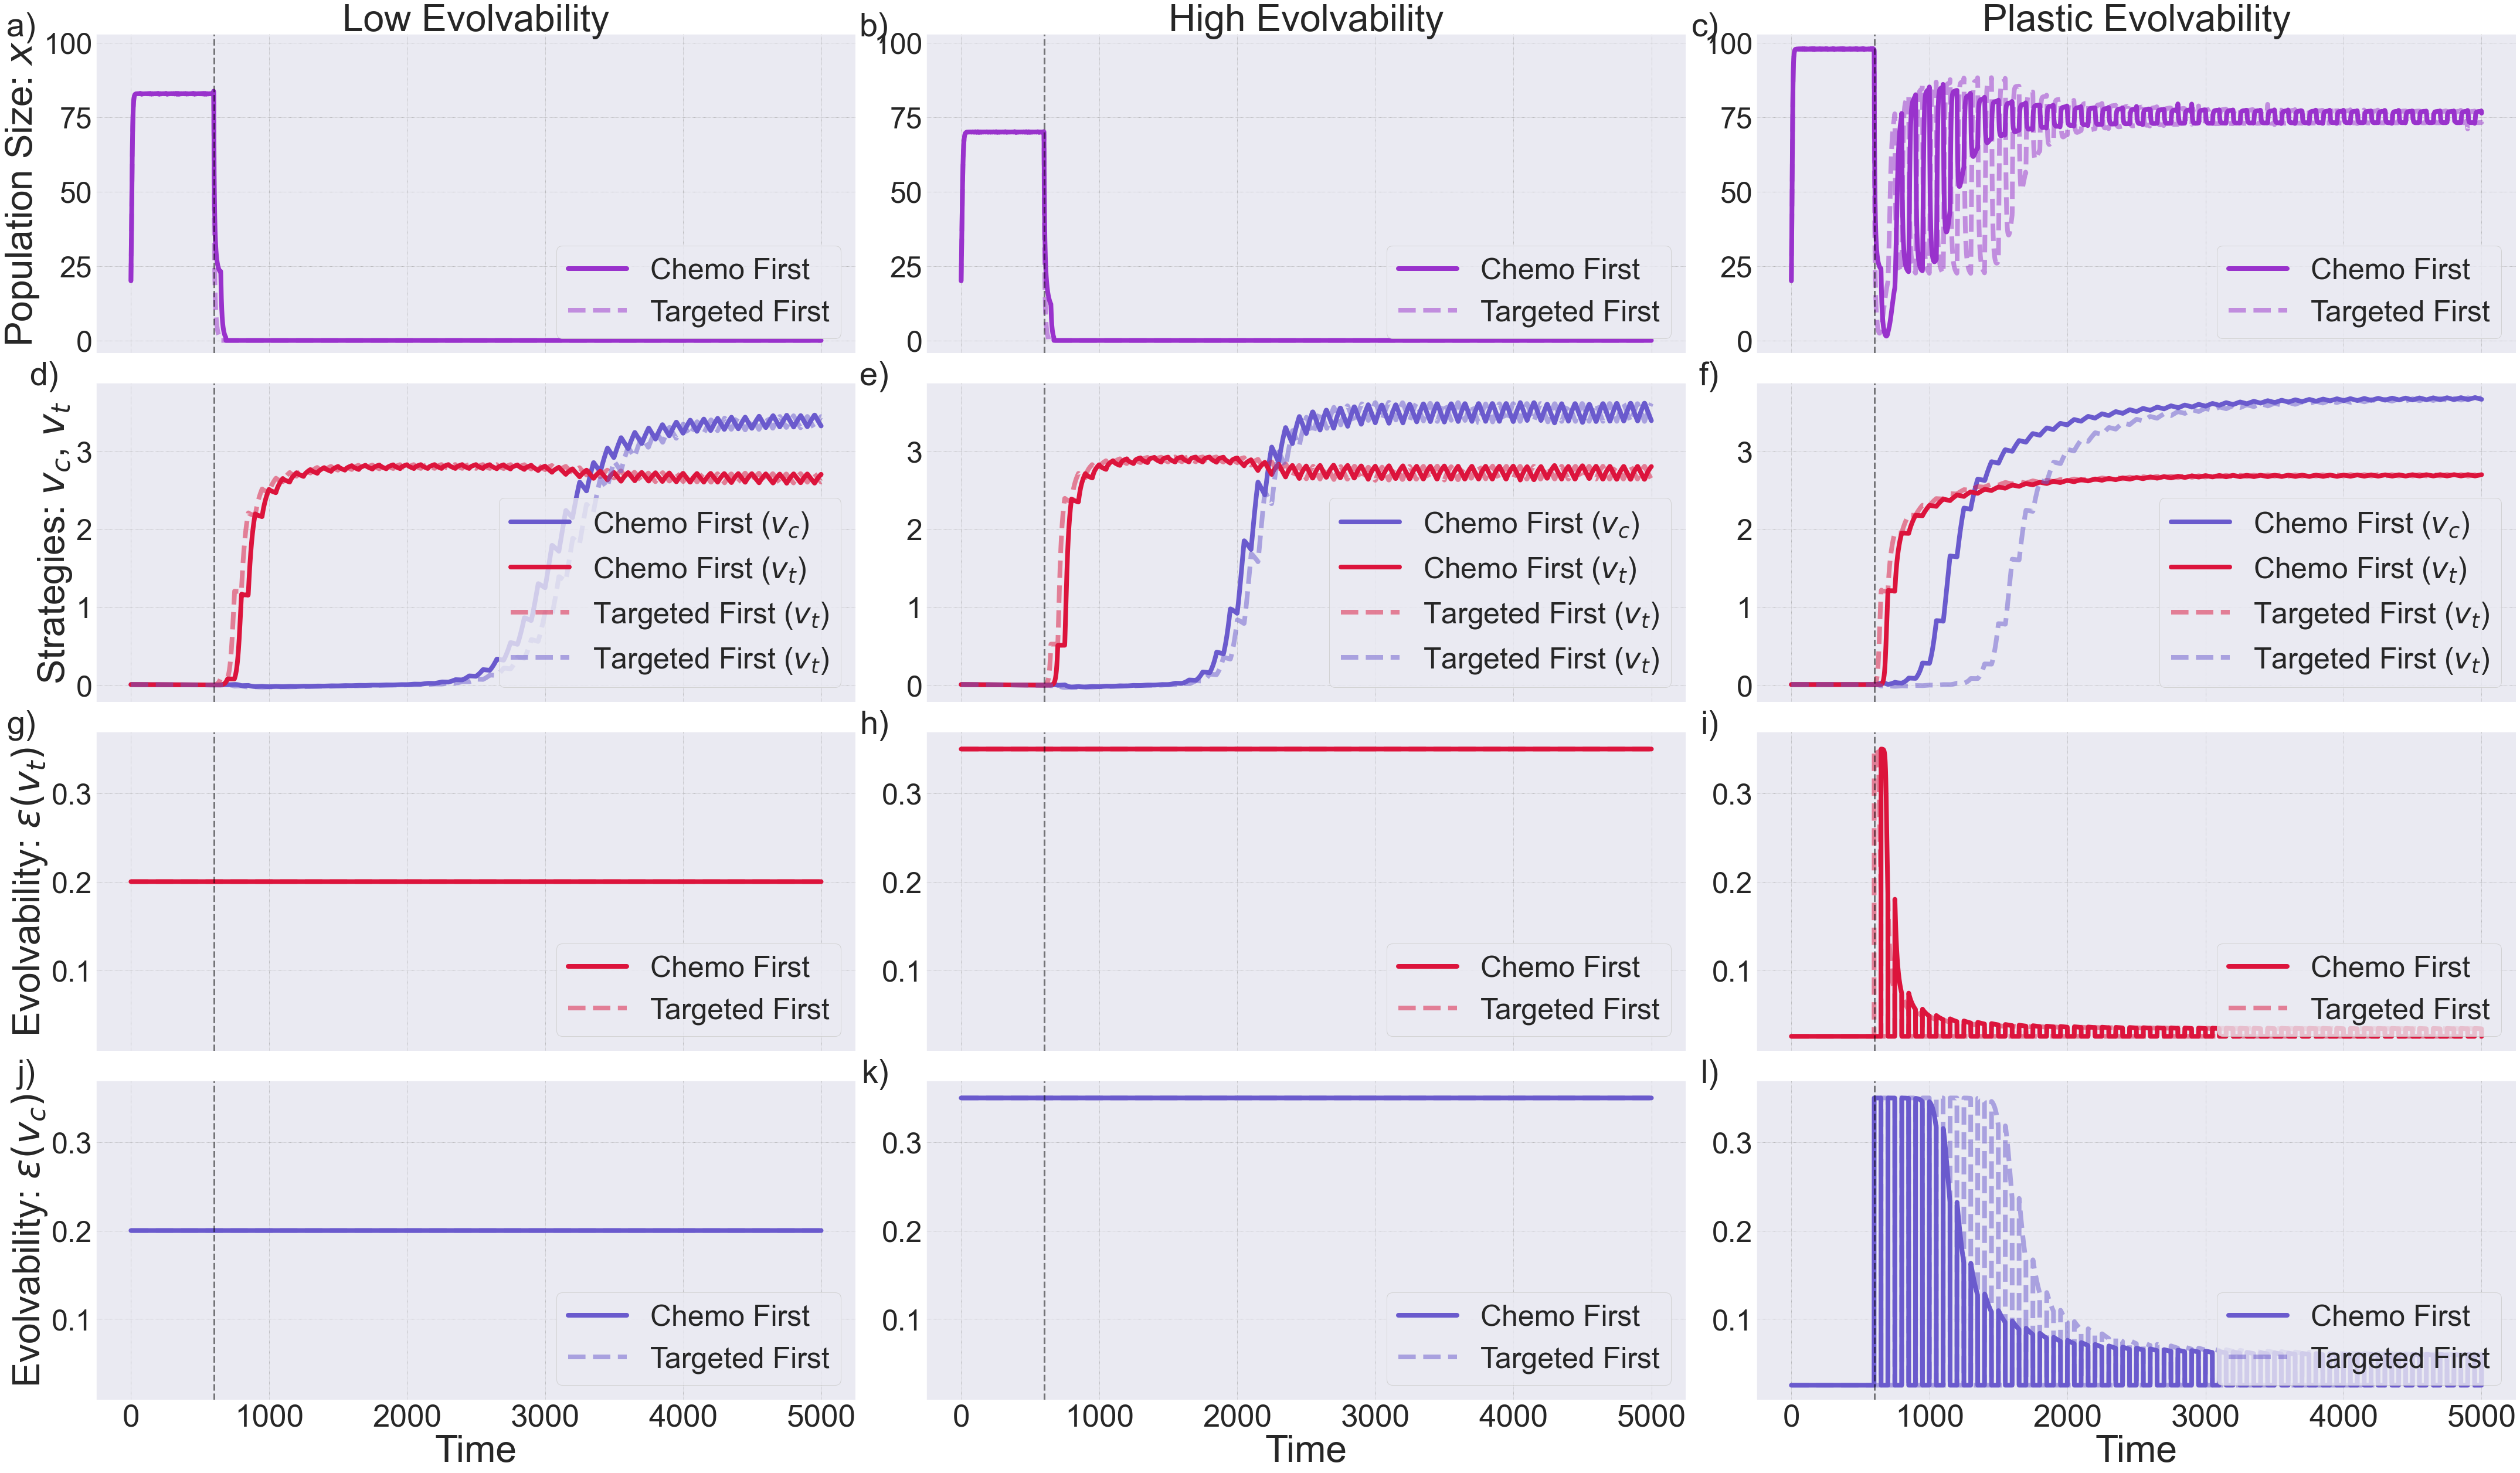

69.90325607783608 82.80644767270408 97.80786642128436


In [62]:
show_parameters("Double bind - short cycle", {"cycle duration": 50}, include_facultative_scaling=True)

linewidth = 8
label_font = 56        # font for subplot labels (a), (b), etc.
font_title = 65        # font for subplot titles
font_axis = 64       # font for axis labels
font_legend = 50       # font for legend
font_ticks_y = 50      # font for y-axis tick labels
font_ticks_x = 53      # font for x-axis tick labels



panel_labels = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)', 'g)', 'h)', 'i)', 'j)', 'k)', 'l)']
label_positions = [(-0.08, 1.07),  # (a) top-first
                   (-0.05, 1.07),  # (b) top-second
                   (-0.05, 1.07),  # (c) top-third
                   (-0.05, 1.07),  # (d) top-fourth
                   (-0.05, 1.07),  # (e) mid-first
                   (-0.05, 1.07),  # (f) mid-second
                   (-0.08, 1.07),  # (g) mid-third
                   (-0.05, 1.07),  # (h) mid-fourth
                   (-0.05, 1.07),  # (i) bottom-first
                   (-0.08, 1.07),  # (j) bottom-second
                    (-0.05, 1.07),  # (k) bottom-third
                    (-0.05, 1.07)]  # (l) bottom-fourth

fig, ax = plt.subplots(4, 3, figsize=(60, 35), sharex=True)



models = [
    ("Low Evolvability", double_bind_low, double_bind_low_switched),
    ("High Evolvability", double_bind_high, double_bind_high_switched),
    ("Plastic Evolvability", double_bind_facultative, double_bind_facultative_switched)]

# --- Row 0: Population ---
for j, (label, model, model_switched) in enumerate(models):
    ax[0, j].plot(model.t, model.y[0], color=double_bind_color, linewidth=linewidth, label="Chemo First")
    ax[0, j].plot(model_switched.t, model_switched.y[0], color=double_bind_color, linestyle="--", linewidth=linewidth, alpha=0.5, label="Targeted First")
    ax[0, j].set_title(f"{label}", fontsize = font_axis)
    ax[0, j].legend(loc="lower right")

# --- Row 1: Strategies (v1, v2) ----
for j, (label, model, model_switched) in enumerate(models):
    ax[1, j].plot(model.t, model.y[1], color=chemo_color, linewidth=linewidth, label="Chemo First ($v_c$)")
    ax[1, j].plot(model.t, model.y[2], color=targeted_color, linewidth=linewidth, label="Chemo First ($v_t$)")
    ax[1, j].plot(model_switched.t, model_switched.y[1], color=targeted_color, linestyle="--", linewidth=linewidth, alpha=0.5, label = "Targeted First ($v_t$)" )
    ax[1, j].plot(model_switched.t, model_switched.y[2], color=chemo_color, linestyle="--", linewidth=linewidth, alpha=0.5, label = "Targeted First ($v_t$)")
    #ax[1, j].set_title(f"{label} )
    ax[1, j].legend(loc="lower right")

# --- Row 2: Evolvability (Targeted) ---
for j, (label, model, model_switched) in enumerate(models):
    ax[2, j].plot(model.t, model.evo_2, color=targeted_color, linewidth=linewidth, label="Chemo First")
    ax[2, j].plot(model_switched.t, model_switched.evo_1, color=targeted_color, linestyle="--", linewidth=linewidth, alpha=0.5, label="Targeted First")
    #ax[2, j].set_title(f"{label} - Evolvability (Targeted): r'$\epsilon(v_t)$'", fontsize = font_axis)
    ax[2, j].legend(loc="lower right")

# --- Row 3: Evolvability (Chemo) ---
for j, (label, model, model_switched) in enumerate(models):
    ax[3, j].plot(model.t, model.evo_1, color=chemo_color, linewidth=linewidth, label="Chemo First")
    ax[3, j].plot(model_switched.t, model_switched.evo_2, color=chemo_color, linestyle="--", linewidth=linewidth, alpha=0.5, label="Targeted First")
    #ax[3, j].set_title(f"{label} - Evolvability (Chemo): '$\epsilon(v_c)$'", fontsize = font_axis)
    ax[3, j].set_xlabel("Time", fontsize = font_axis)
    ax[3, j].legend(loc="lower right")

# --- Y labels (left column only) ---
ax[0, 0].set_ylabel("Population Size: $x$", fontsize=font_axis)
ax[1, 0].set_ylabel(r"Strategies: $v_c$, $v_t$", fontsize=font_axis)
ax[2, 0].set_ylabel(r"Evolvability: $\epsilon(v_t)$", fontsize=font_axis)
ax[3, 0].set_ylabel(r"Evolvability: $\epsilon(v_c)$", fontsize=font_axis)


# --- Match y-limits row-wise ---
match_ylim_by_row(ax)

# Final polish
for i, axes in enumerate(ax.flat):
    axes.axvline(x=high_evo_constant_model_chemo.therapy_start_time, color='black',
                 linestyle='--', linewidth=3, alpha=0.5)
    axes.tick_params(axis='x', labelsize=font_ticks_x)
    axes.tick_params(axis='y', labelsize=font_ticks_y)

    axes.legend(fontsize=font_legend, loc = "lower right")

    x_pos, y_pos = label_positions[i]
    axes.text(x_pos, y_pos, panel_labels[i], transform=axes.transAxes,
              fontsize=label_font, va='top', ha='right')
    
plt.tight_layout()
plt.show()


print(double_bind_high.y[0][500], double_bind_low.y[0][500], double_bind_facultative.y[0][500])


### Double Bind with Longer cycle duration

Non-alternative case: Double bind - long cycle


,Parameter,Value
0,growth rate (r),0.280000
1,evolvability cost (d),0.127000
2,maximum carrying capacity (K_m),100.000000
3,carrying-capacity breadth (sigma_k),10.000000
4,baseline evolvability (m),0.025000
5,low fixed evolvability,0.200000
6,high/plastic evolvability ceiling,0.350000
7,chemotherapy efficacy (s_c),0.170000
8,chemotherapy breadth (sigma_sc),2.449490
9,targeted efficacy (s_t),0.300000


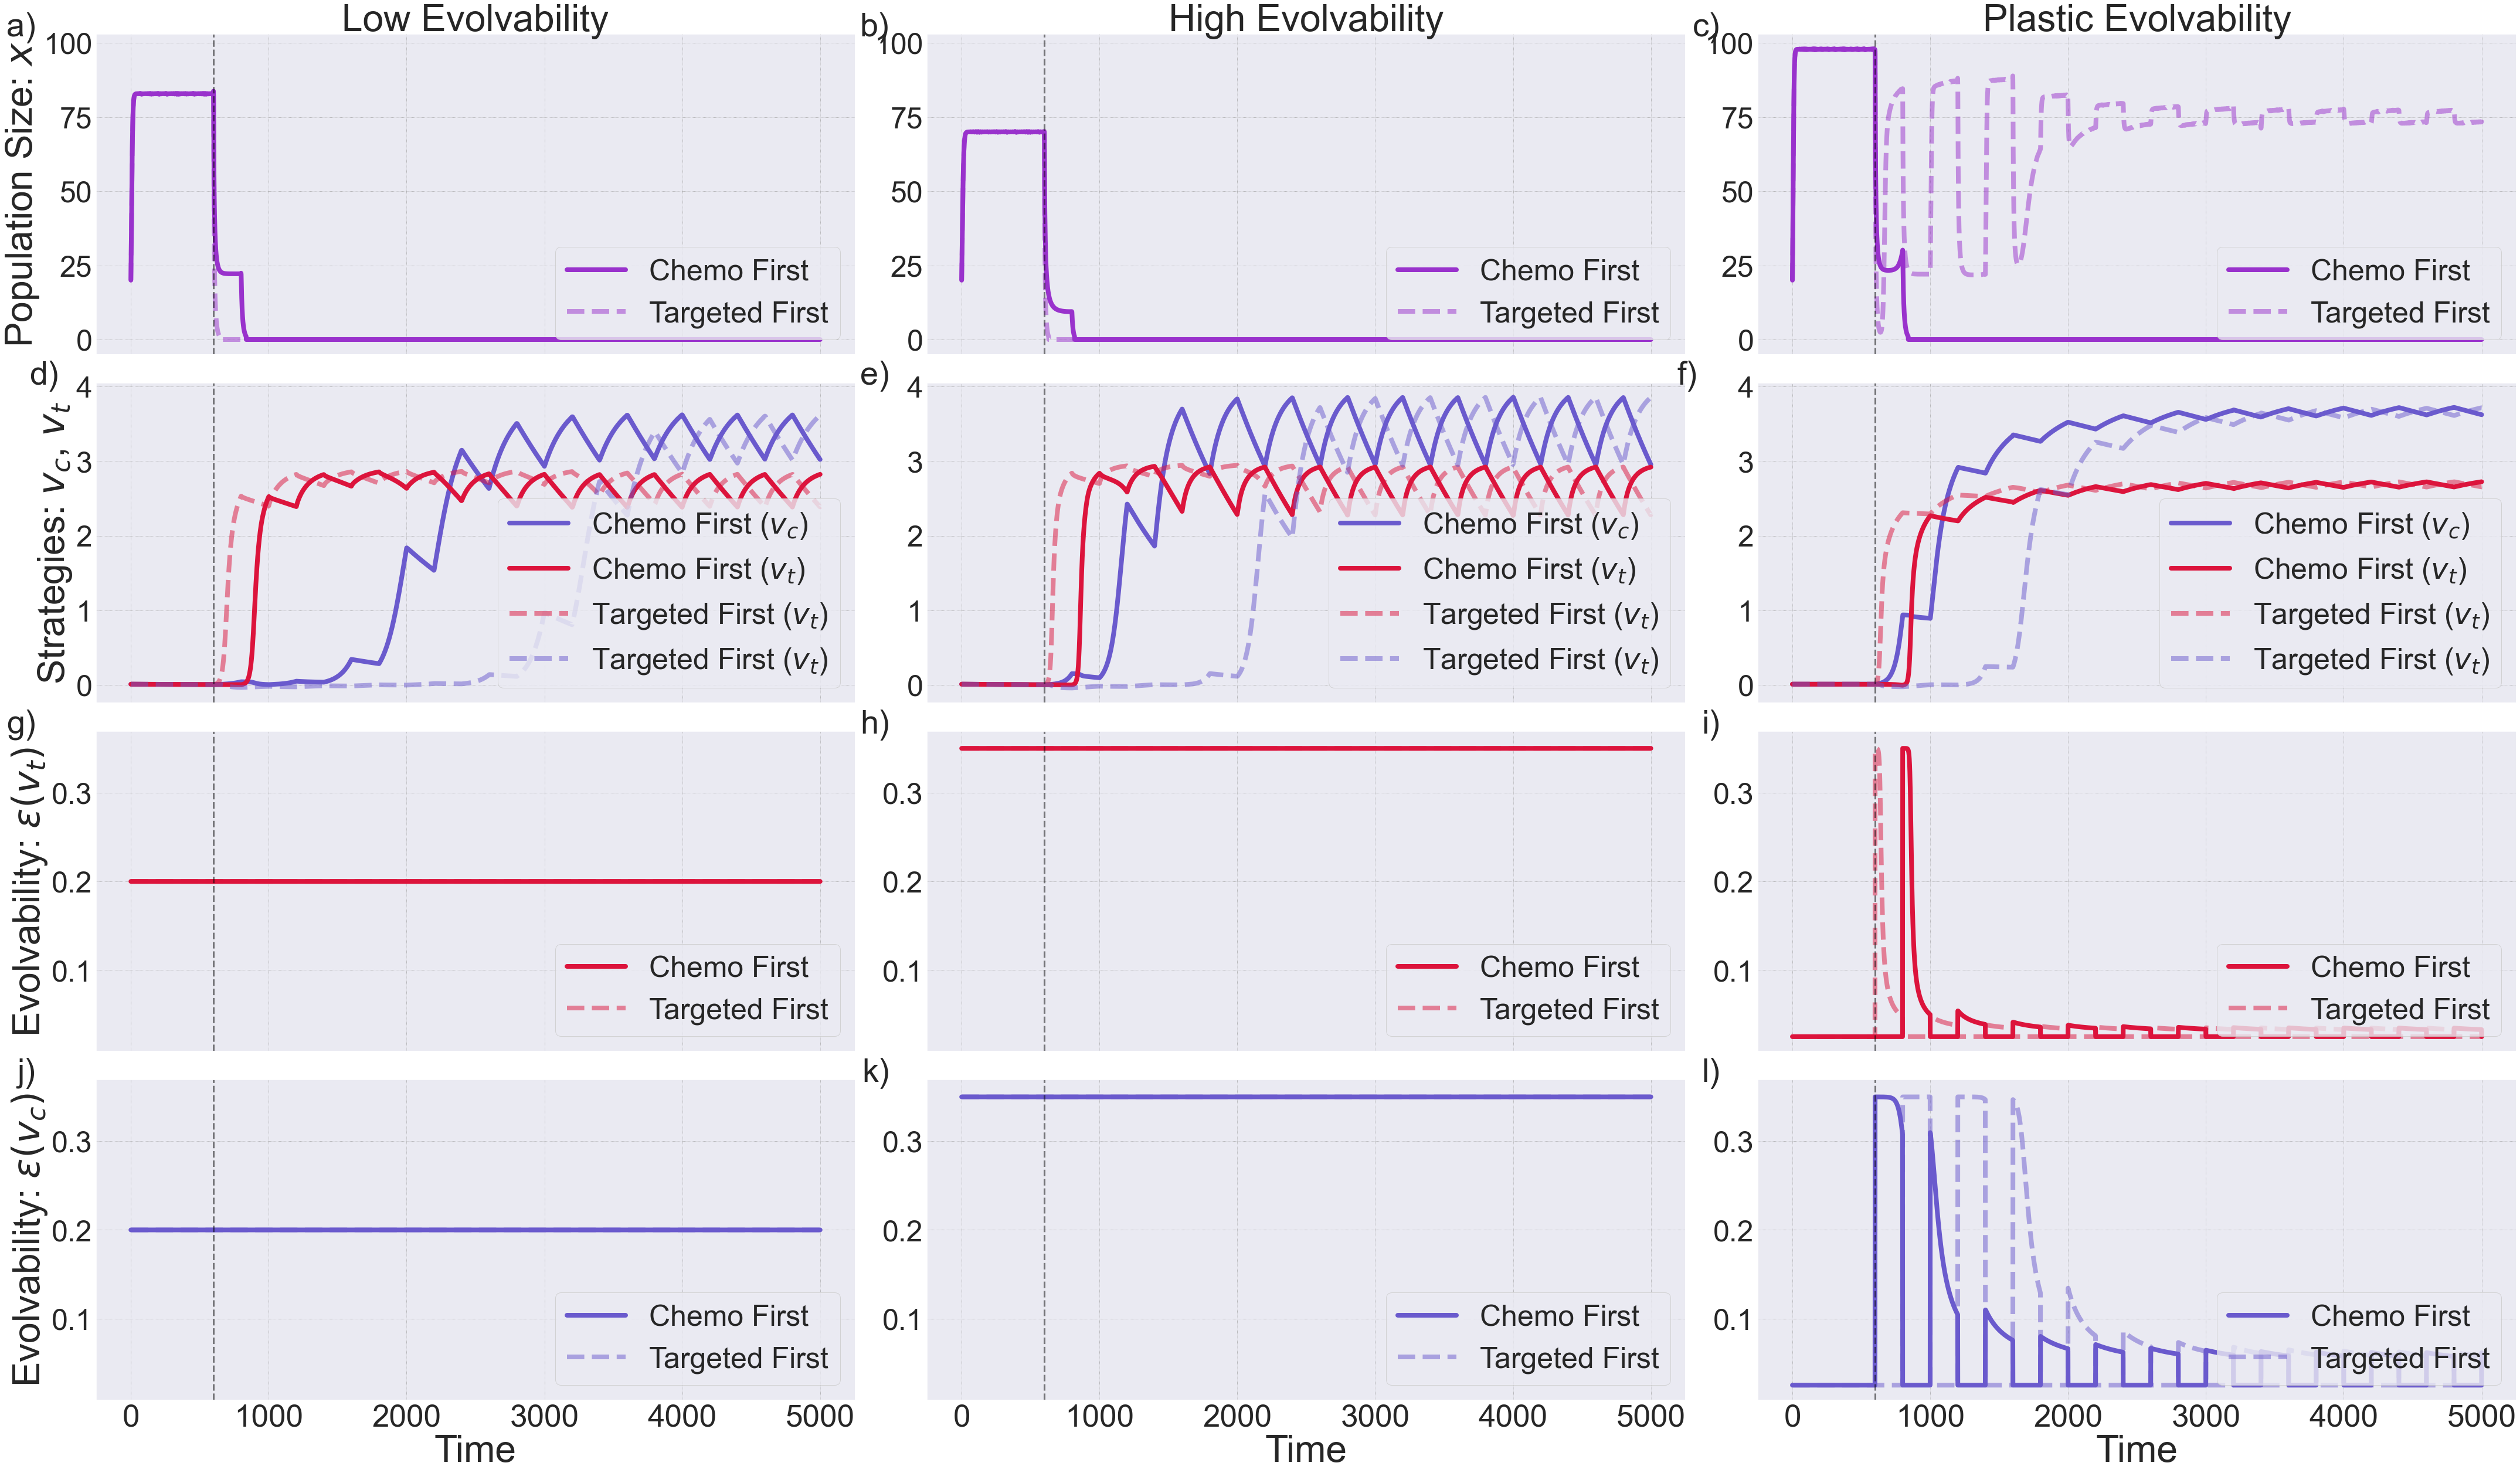

In [64]:
show_parameters("Double bind - long cycle", {"cycle duration": 200}, include_facultative_scaling=True)

cycle_long = 200

for model in [double_bind_facultative, double_bind_low, double_bind_high] + [double_bind_facultative_switched, double_bind_low_switched, double_bind_high_switched]:
    model.set_params(cycle_duration = cycle_long)
    model.get_evolvability_scaling_factor(HIGH_EVOLVABILITY)
    #print(model.evolvability_scaling_factor_1, model.evolvability_scaling_factor_2)
    model.run()
    model.apply_extinction()

linewidth = 8
label_font = 56        # font for subplot labels (a), (b), etc.
font_title = 65        # font for subplot titles
font_axis = 64       # font for axis labels
font_legend = 50       # font for legend
font_ticks_y = 50      # font for y-axis tick labels
font_ticks_x = 53      # font for x-axis tick labels


panel_labels = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)', 'g)', 'h)', 'i)', 'j)', 'k)', 'l)']
label_positions = [(-0.08, 1.07),  # (a) top-first
                   (-0.05, 1.07),  # (b) top-second
                   (-0.05, 1.07),  # (c) top-third
                   (-0.05, 1.07),  # (d) top-fourth
                   (-0.05, 1.07),  # (e) mid-first
                   (-0.08, 1.07),  # (f) mid-second
                   (-0.08, 1.07),  # (g) mid-third
                   (-0.05, 1.07),  # (h) mid-fourth
                   (-0.05, 1.07),  # (i) bottom-first
                   (-0.08, 1.07),  # (j) bottom-second
                    (-0.05, 1.07),  # (k) bottom-third
                    (-0.05, 1.07)]  # (l) bottom-fourth

fig, ax = plt.subplots(4, 3, figsize=(60, 35), sharex=True)



models = [
    ("Low Evolvability", double_bind_low, double_bind_low_switched),
    ("High Evolvability", double_bind_high, double_bind_high_switched),
    ("Plastic Evolvability", double_bind_facultative, double_bind_facultative_switched)]

# --- Row 0: Population ---
for j, (label, model, model_switched) in enumerate(models):
    ax[0, j].plot(model.t, model.y[0], color=double_bind_color, linewidth=linewidth, label="Chemo First")
    ax[0, j].plot(model_switched.t, model_switched.y[0], color=double_bind_color, linestyle="--", linewidth=linewidth, alpha=0.5, label="Targeted First")
    ax[0, j].set_title(f"{label}", fontsize = font_axis)
    ax[0, j].legend(loc="lower right")

# --- Row 1: Strategies (v1, v2) ----
for j, (label, model, model_switched) in enumerate(models):
    ax[1, j].plot(model.t, model.y[1], color=chemo_color, linewidth=linewidth, label="Chemo First ($v_c$)")
    ax[1, j].plot(model.t, model.y[2], color=targeted_color, linewidth=linewidth, label="Chemo First ($v_t$)")
    ax[1, j].plot(model_switched.t, model_switched.y[1], color=targeted_color, linestyle="--", linewidth=linewidth, alpha=0.5, label = "Targeted First ($v_t$)" )
    ax[1, j].plot(model_switched.t, model_switched.y[2], color=chemo_color, linestyle="--", linewidth=linewidth, alpha=0.5, label = "Targeted First ($v_t$)")
    ax[1, j].legend(loc="lower right")

# --- Row 2: Evolvability (Targeted) ---
for j, (label, model, model_switched) in enumerate(models):
    ax[2, j].plot(model.t, model.evo_2, color=targeted_color, linewidth=linewidth, label="Chemo First")
    ax[2, j].plot(model_switched.t, model_switched.evo_1, color=targeted_color, linestyle="--", linewidth=linewidth, alpha=0.5, label="Targeted First")
    ax[2, j].legend(loc="lower right")

# --- Row 3: Evolvability (Chemo) ---
for j, (label, model, model_switched) in enumerate(models):
    ax[3, j].plot(model.t, model.evo_1, color=chemo_color, linewidth=linewidth, label="Chemo First")
    ax[3, j].plot(model_switched.t, model_switched.evo_2, color=chemo_color, linestyle="--", linewidth=linewidth, alpha=0.5, label="Targeted First")
    ax[3, j].set_xlabel("Time", fontsize = font_axis)
    ax[3, j].legend(loc="lower right")

# --- Y labels (left column only) ---
ax[0, 0].set_ylabel("Population Size: $x$", fontsize=font_axis)
ax[1, 0].set_ylabel(r"Strategies: $v_c$, $v_t$", fontsize=font_axis)
ax[2, 0].set_ylabel(r"Evolvability: $\epsilon(v_t)$", fontsize=font_axis)
ax[3, 0].set_ylabel(r"Evolvability: $\epsilon(v_c)$", fontsize=font_axis)


# --- Match y-limits row-wise ---
match_ylim_by_row(ax)

# Final polish
for i, axes in enumerate(ax.flat):
    axes.axvline(x=high_evo_constant_model_chemo.therapy_start_time, color='black',
                 linestyle='--', linewidth=3, alpha=0.5)
    axes.tick_params(axis='x', labelsize=font_ticks_x)
    axes.tick_params(axis='y', labelsize=font_ticks_y)

    axes.legend(fontsize=font_legend, loc = "lower right")

    x_pos, y_pos = label_positions[i]
    axes.text(x_pos, y_pos, panel_labels[i], transform=axes.transAxes,
              fontsize=label_font, va='top', ha='right')
    
plt.tight_layout()
plt.show()



## Combination Therapy

### Full Drug Efficacy

In [65]:
init = [20, 0.01, 0.01]
t_max = 5000

# Facultative
combination_facultative = CombinationModel(
    init=init,
    t_max=t_max,
    growth_rate=growth_rate,
    carrying_capacity_std=maximum_carrying_capacity_std,
    efficacy_1=efficacy_chemo,
    efficacy_2=efficacy_targeted,
    efficacy_std_1=efficacy_chemo_std,
    efficacy_std_2=efficacy_targeted_std,
    evolvability_value=baseline_heterogeneity,
    facultative_evolvability=True,
    covariance=cov
)


# Low evolvability
combination_low = CombinationModel(
    init=init,
    t_max=t_max,
    growth_rate=growth_rate,
    carrying_capacity_std=maximum_carrying_capacity_std,
    efficacy_1=efficacy_chemo,
    efficacy_2=efficacy_targeted,
    efficacy_std_1=efficacy_chemo_std,
    efficacy_std_2=efficacy_targeted_std,
    evolvability_value=LOW_EVOLVABILITY,
    facultative_evolvability=False,
    covariance=cov
)



# High evolvability
combination_high = CombinationModel(
    init=init,
    t_max=t_max,
    growth_rate=growth_rate,
    carrying_capacity_std=maximum_carrying_capacity_std,
    efficacy_1=efficacy_chemo,
    efficacy_2=efficacy_targeted,
    efficacy_std_1=efficacy_chemo_std,
    efficacy_std_2=efficacy_targeted_std,
    evolvability_value=HIGH_EVOLVABILITY,
    facultative_evolvability=False,
    covariance=cov
)


for model in [combination_facultative, combination_low, combination_high]:
    model.get_evolvability_scaling_factor(HIGH_EVOLVABILITY)
    model.run()
    model.apply_extinction()



### Half Drug Efficacy

In [66]:
init = [20, 0.01, 0.01]
t_max = 5000

# Facultative
combination_facultative_half = CombinationModel(
    init=init,
    t_max=t_max,
    growth_rate=growth_rate,
    carrying_capacity_std=maximum_carrying_capacity_std,
    efficacy_1=efficacy_chemo / 2,
    efficacy_2=efficacy_targeted /2,
    efficacy_std_1=efficacy_chemo_std,
    efficacy_std_2=efficacy_targeted_std,
    evolvability_value=baseline_heterogeneity,
    facultative_evolvability=True,
    covariance=cov
)


# Low evolvability
combination_low_half = CombinationModel(
    init=init,
    t_max=t_max,
    growth_rate=growth_rate,
    carrying_capacity_std=maximum_carrying_capacity_std,
    efficacy_1=efficacy_chemo/2,
    efficacy_2=efficacy_targeted/2,
    efficacy_std_1=efficacy_chemo_std,
    efficacy_std_2=efficacy_targeted_std,
    evolvability_value=LOW_EVOLVABILITY,
    facultative_evolvability=False,
    covariance=cov
)



# High evolvability
combination_high_half = CombinationModel(
    init=init,
    t_max=t_max,
    growth_rate=growth_rate,
    carrying_capacity_std=maximum_carrying_capacity_std,
    efficacy_1=efficacy_chemo/2,
    efficacy_2=efficacy_targeted/2,
    efficacy_std_1=efficacy_chemo_std,
    efficacy_std_2=efficacy_targeted_std,
    evolvability_value=HIGH_EVOLVABILITY,
    facultative_evolvability=False,
    covariance=cov
)


for model in [combination_facultative_half, combination_low_half, combination_high_half]:
    model.get_evolvability_scaling_factor(HIGH_EVOLVABILITY)
    model.run()
    model.apply_extinction()



Non-alternative case: Combination therapy


,Parameter,Value
0,growth rate (r),0.28
1,evolvability cost (d),0.127
2,maximum carrying capacity (K_m),100
3,carrying-capacity breadth (sigma_k),10
4,baseline evolvability (m),0.025
5,low fixed evolvability,0.2
6,high/plastic evolvability ceiling,0.35
7,chemotherapy efficacy (s_c),0.17
8,chemotherapy breadth (sigma_sc),2.44949
9,targeted efficacy (s_t),0.3


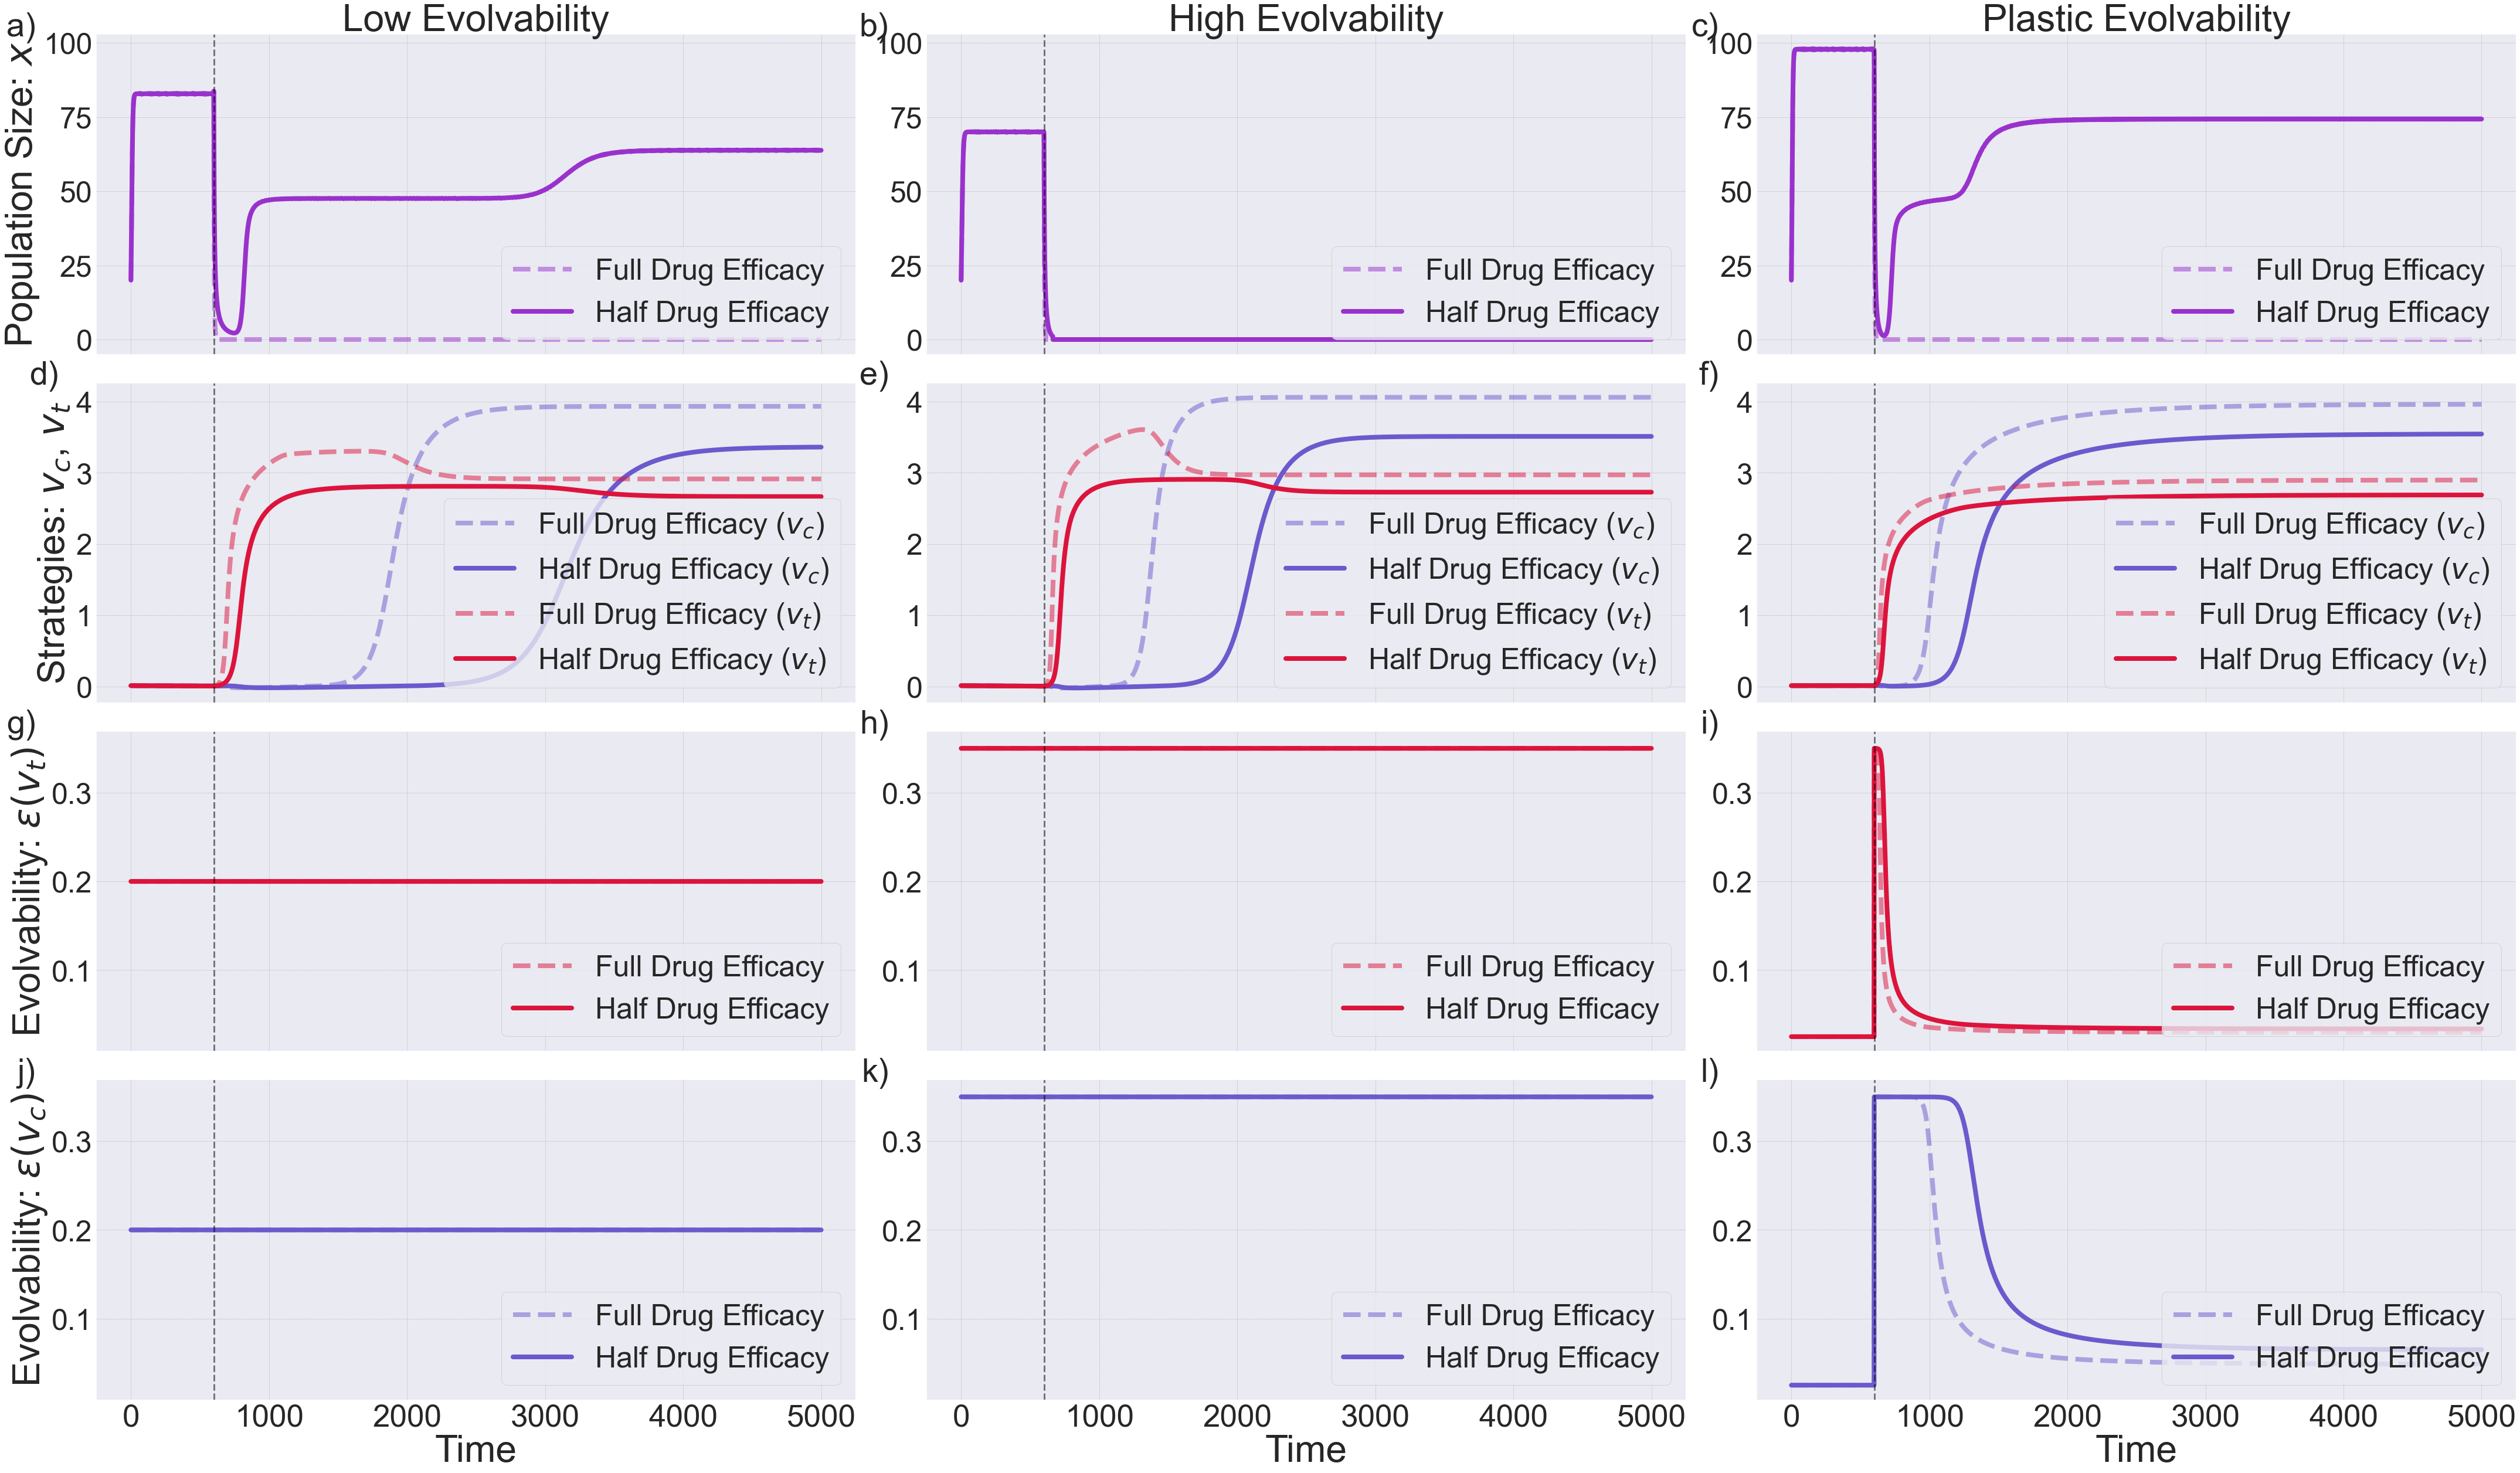

In [68]:
show_parameters("Combination therapy", {"dose levels": "full and half"}, include_facultative_scaling=True, include_half_dose_scaling=True)

linewidth = 8
label_font = 56        # font for subplot labels (a), (b), etc.
font_title = 65        # font for subplot titles
font_axis = 64       # font for axis labels
font_legend = 50       # font for legend
font_ticks_y = 50      # font for y-axis tick labels
font_ticks_x = 53      # font for x-axis tick labels


panel_labels = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)', 'g)', 'h)', 'i)', 'j)', 'k)', 'l)']
label_positions = [(-0.08, 1.07),  # (a) top-first
                   (-0.05, 1.07),  # (b) top-second
                   (-0.05, 1.07),  # (c) top-third
                   (-0.05, 1.07),  # (d) top-fourth
                   (-0.05, 1.07),  # (e) mid-first
                   (-0.05, 1.07),  # (f) mid-second
                   (-0.08, 1.07),  # (g) mid-third
                   (-0.05, 1.07),  # (h) mid-fourth
                   (-0.05, 1.07),  # (i) bottom-first
                   (-0.08, 1.07),  # (j) bottom-second
                    (-0.05, 1.07),  # (k) bottom-third
                    (-0.05, 1.07)]  # (l) bottom-fourth

fig, ax = plt.subplots(4, 3, figsize=(60, 35), sharex=True)



models = [
    ("Low Evolvability", combination_low, combination_low_half),
    ("High Evolvability", combination_high, combination_high_half),
    ("Plastic Evolvability", combination_facultative, combination_facultative_half)]

# --- Row 0: Population ---
for j, (label, model, model_half) in enumerate(models):
    ax[0, j].plot(model.t, model.y[0], color=double_bind_color, linewidth=linewidth, linestyle = '--', alpha=0.5, label="Full Drug Efficacy")
    ax[0, j].plot(model_half.t, model_half.y[0], color=double_bind_color, linewidth=linewidth, linestyle = '-', label="Half Drug Efficacy")
    ax[0, j].set_title(f"{label}", fontsize = font_axis)
    ax[0, j].legend(loc="lower right")

# --- Row 1: Strategies (v1, v2) ----
for j, (label, model, model_half) in enumerate(models):
    ax[1, j].plot(model.t, model.y[1], color=chemo_color, linewidth=linewidth, linestyle = '--', alpha=0.5, label="Full Drug Efficacy ($v_c$)")
    ax[1, j].plot(model_half.t, model_half.y[1], color=chemo_color, linewidth=linewidth, linestyle = '-', label="Half Drug Efficacy ($v_c$)")
    ax[1, j].plot(model.t, model.y[2], color=targeted_color, linewidth=linewidth, linestyle = '--', alpha=0.5, label="Full Drug Efficacy ($v_t$)")
    ax[1, j].plot(model_half.t, model_half.y[2], color=targeted_color, linewidth=linewidth, linestyle = '-', label="Half Drug Efficacy ($v_t$)")
    #ax[1, j].set_title(f"{label} )
    ax[1, j].legend(loc="lower right")

# --- Row 2: Evolvability (Targeted) ---
for j, (label, model, model_half) in enumerate(models):
    ax[2, j].plot(model.t, model.evo_2, color=targeted_color, linewidth=linewidth, linestyle = '--', alpha=0.5, label="Full Drug Efficacy")
    ax[2, j].plot(model_half.t, model_half.evo_2, color=targeted_color, linewidth=linewidth, linestyle = '-', label="Half Drug Efficacy")
    ax[2, j].legend(loc="lower right")

# --- Row 3: Evolvability (Chemo) ---
for j, (label, model, model_half) in enumerate(models):
    ax[3, j].plot(model.t, model.evo_1, color=chemo_color, linewidth=linewidth, linestyle = '--', alpha=0.5, label="Full Drug Efficacy")
    ax[3, j].plot(model_half.t, model_half.evo_1, color=chemo_color, linewidth=linewidth, linestyle = '-', label="Half Drug Efficacy")
    ax[3, j].set_xlabel("Time", fontsize = font_axis)
    ax[3, j].legend(loc="lower right")

# --- Y labels (left column only) ---
ax[0, 0].set_ylabel("Population Size: $x$", fontsize=font_axis)
ax[1, 0].set_ylabel(r"Strategies: $v_c$, $v_t$", fontsize=font_axis)
ax[2, 0].set_ylabel(r"Evolvability: $\epsilon(v_t)$", fontsize=font_axis)
ax[3, 0].set_ylabel(r"Evolvability: $\epsilon(v_c)$", fontsize=font_axis)


# --- Match y-limits row-wise ---
match_ylim_by_row(ax)

# Final polish
for i, axes in enumerate(ax.flat):
    axes.axvline(x=combination_facultative.therapy_start_time, color='black',
                 linestyle='--', linewidth=3, alpha=0.5)
    axes.tick_params(axis='x', labelsize=font_ticks_x)
    axes.tick_params(axis='y', labelsize=font_ticks_y)

    axes.legend(fontsize=font_legend, loc = "lower right")

    x_pos, y_pos = label_positions[i]
    axes.text(x_pos, y_pos, panel_labels[i], transform=axes.transAxes,
              fontsize=label_font, va='top', ha='right')
    
plt.tight_layout()
plt.show()


# print(double_bind_high.y[0][500])

# print(double_bind_low.y[0][500])

# print(double_bind_facultative.y[0][500])



## Extinction summary


In [18]:
from pathlib import Path


def non_alternative_extinction_time(model):
    extinct = np.flatnonzero(model.y[0] == 0)
    return int(model.t[extinct[0]]) if extinct.size else np.nan


non_alternative_summary_rows = []


def add_non_alternative_summary_row(figure, population, regimen, model):
    non_alternative_summary_rows.append(
        {
            "figure": figure,
            "population": population,
            "regimen": regimen,
            "extinction_time": non_alternative_extinction_time(model),
            "final_population": model.y[0, -1],
        }
    )


# Continuous single therapy: Figures 3 and 4.
for population, chemo_model, targeted_model in [
    ("Low Evolvability", low_evo_constant_model_chemo, low_evo_constant_model_targeted),
    ("High Evolvability", high_evo_constant_model_chemo, high_evo_constant_model_targeted),
]:
    add_non_alternative_summary_row("3", population, "Chemotherapy", chemo_model)
    add_non_alternative_summary_row("3", population, "Targeted therapy", targeted_model)

add_non_alternative_summary_row("4", "Plastic Evolvability", "Chemotherapy", facultative_model_chemo)
add_non_alternative_summary_row("4", "Plastic Evolvability", "Targeted therapy", facultative_model_targeted)


# Intermittent therapy: Figure S1 and Figure 5.
for population, model in [
    ("Low Evolvability", low_evo_intermittent_chemo),
    ("High Evolvability", high_evo_intermittent_chemo),
    ("Plastic Evolvability", facultative_intermittent_chemo),
]:
    add_non_alternative_summary_row("S1", population, "Intermittent chemotherapy", model)

for population, model in [
    ("Low Evolvability", low_evo_intermittent_targeted),
    ("High Evolvability", high_evo_intermittent_targeted),
    ("Plastic Evolvability", facultative_intermittent_targeted),
]:
    add_non_alternative_summary_row("5", population, "Intermittent targeted therapy", model)


# Double bind: Figure 6 (cycle 50) and Figure 7 (cycle 200).
for population, chemo_first, targeted_first in double_bind_short_models:
    add_non_alternative_summary_row("6", population, "Chemo first", chemo_first)
    add_non_alternative_summary_row("6", population, "Targeted first", targeted_first)

for population, chemo_first, targeted_first in [
    ("Low Evolvability", double_bind_low, double_bind_low_switched),
    ("High Evolvability", double_bind_high, double_bind_high_switched),
    ("Plastic Evolvability", double_bind_facultative, double_bind_facultative_switched),
]:
    add_non_alternative_summary_row("7", population, "Chemo first", chemo_first)
    add_non_alternative_summary_row("7", population, "Targeted first", targeted_first)


# Combination therapy: Figure S2.
for population, full, half in [
    ("Low Evolvability", combination_low, combination_low_half),
    ("High Evolvability", combination_high, combination_high_half),
    ("Plastic Evolvability", combination_facultative, combination_facultative_half),
]:
    add_non_alternative_summary_row("S2", population, "Full efficacy", full)
    add_non_alternative_summary_row("S2", population, "Half efficacy", half)


non_alternative_summary = pd.DataFrame(non_alternative_summary_rows)
non_alternative_summary_output_dir = Path("outputs/non_alternative_summary").resolve()
non_alternative_summary_output_dir.mkdir(parents=True, exist_ok=True)
non_alternative_summary.to_csv(
    non_alternative_summary_output_dir / "non_alternative_extinction_summary.csv",
    index=False,
)
non_alternative_summary


,figure,population,regimen,extinction_time,final_population
0,3,Low Evolvability,Chemotherapy,NaN,73.988657
1,3,Low Evolvability,Targeted therapy,661.0,0.000000
2,3,High Evolvability,Chemotherapy,NaN,68.115344
3,3,High Evolvability,Targeted therapy,NaN,75.791249
4,4,Plastic Evolvability,Chemotherapy,NaN,79.773345
5,4,Plastic Evolvability,Targeted therapy,NaN,89.213690
6,S1,Low Evolvability,Intermittent chemotherapy,NaN,82.030751
7,S1,High Evolvability,Intermittent chemotherapy,NaN,75.284687
8,S1,Plastic Evolvability,Intermittent chemotherapy,NaN,85.814603
9,5,Low Evolvability,Intermittent targeted therapy,NaN,84.929559


# Alternative case

Supplementary Figures S3-S6 use a separate, explicit parameter set. No commenting or environment switch selects between cases.


In [19]:
import os
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from models.combination_model import CombinationModel
from models.double_bind_model import DoubleBindModel
from utils import match_ylim_by_row

sns.set_style("darkgrid", {"grid.color": ".6", "grid.linestyle": ":"})

OUTPUT_DIR = Path(
    os.environ.get("CANCER_EVO_OUTPUT_DIR", "outputs/supplementary_s3_s6")
).resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figures will be written to: {OUTPUT_DIR}")


Figures will be written to: C:\Users\80019048\Projects\Evolvability-Determines-Therapy-Outcomes\outputs\supplementary_s3_s6


## Alternative-case parameters (Table S1)


In [70]:
growth_rate_alternative = 0.32
CARRYING_CAPACITY = 100
CARRYING_CAPACITY_STD = 10
cost_of_evolvability_alternative = 0.12
BASELINE_HETEROGENEITY = 0.025

EFFICACY_CHEMO = 0.17
efficacy_targeted_alternative = 0.30
EFFICACY_STD_CHEMO = np.sqrt(6)
EFFICACY_STD_TARGETED = np.sqrt(2)

LOW_EVOLVABILITY_ALTERNATIVE = 0.15
HIGH_EVOLVABILITY_ALTERNATIVE = 0.40
COVARIANCE = 0.015

THERAPY_START = 600
T_MAX = 5000
INIT = [20, 0.01, 0.01]

CHEMO_COLOR = "#6A5ACD"
TARGETED_COLOR = "#dc143c"
DOUBLE_BIND_COLOR = "#9932CC"


def show_alternative_parameters(
    plot_name,
    extra_parameters=None,
    include_facultative_scaling=False,
    include_half_dose_scaling=False,
):
    parameters = {
        "growth rate (r)": growth_rate_alternative,
        "evolvability cost (d)": cost_of_evolvability_alternative,
        "maximum carrying capacity (K_m)": CARRYING_CAPACITY,
        "carrying-capacity breadth (sigma_k)": CARRYING_CAPACITY_STD,
        "baseline evolvability (m)": BASELINE_HETEROGENEITY,
        "low fixed evolvability": LOW_EVOLVABILITY_ALTERNATIVE,
        "high/plastic evolvability ceiling": HIGH_EVOLVABILITY_ALTERNATIVE,
        "chemotherapy efficacy (s_c)": EFFICACY_CHEMO,
        "chemotherapy breadth (sigma_sc)": EFFICACY_STD_CHEMO,
        "targeted efficacy (s_t)": efficacy_targeted_alternative,
        "targeted breadth (sigma_st)": EFFICACY_STD_TARGETED,
        "covariance magnitude (delta)": COVARIANCE,
    }

    if include_facultative_scaling:
        parameters.update({
            "facultative scaling factor (f_c)": (
                HIGH_EVOLVABILITY_ALTERNATIVE - BASELINE_HETEROGENEITY
            ) / EFFICACY_CHEMO,
            "facultative scaling factor (f_t)": (
                HIGH_EVOLVABILITY_ALTERNATIVE - BASELINE_HETEROGENEITY
            ) / efficacy_targeted_alternative,
        })

    if include_half_dose_scaling:
        parameters.update({
            "half-dose facultative scaling factor (f_c)": (
                HIGH_EVOLVABILITY_ALTERNATIVE - BASELINE_HETEROGENEITY
            ) / (EFFICACY_CHEMO / 2),
            "half-dose facultative scaling factor (f_t)": (
                HIGH_EVOLVABILITY_ALTERNATIVE - BASELINE_HETEROGENEITY
            ) / (efficacy_targeted_alternative / 2),
        })

    display_parameter_table(
        "Alternative case",
        plot_name,
        parameters,
        extra_parameters,
    )


## Scenario construction and plotting helpers


In [71]:
def common_kwargs():
    return dict(
        init=INIT,
        t_max=T_MAX,
        growth_rate=growth_rate_alternative,
        carrying_capacity=CARRYING_CAPACITY,
        carrying_capacity_std=CARRYING_CAPACITY_STD,
        evolvability_cost=cost_of_evolvability_alternative,
        therapy_start_time=THERAPY_START,
        therapy_max_eff=0,
        efficacy_1=EFFICACY_CHEMO,
        efficacy_2=efficacy_targeted_alternative,
        efficacy_std_1=EFFICACY_STD_CHEMO,
        efficacy_std_2=EFFICACY_STD_TARGETED,
        covariance=COVARIANCE,
    )


def run_model(model):
    model.get_evolvability_scaling_factor(HIGH_EVOLVABILITY_ALTERNATIVE)
    model.run()
    model.apply_extinction()
    return model


def make_double_bind_models(cycle_duration):
    facultative = DoubleBindModel(
        **common_kwargs(),
        evolvability_value=BASELINE_HETEROGENEITY,
        facultative_evolvability=True,
        cycle_duration=cycle_duration,
    )
    low = DoubleBindModel(
        **common_kwargs(),
        evolvability_value=LOW_EVOLVABILITY_ALTERNATIVE,
        facultative_evolvability=False,
        cycle_duration=cycle_duration,
    )
    high = DoubleBindModel(
        **common_kwargs(),
        evolvability_value=HIGH_EVOLVABILITY_ALTERNATIVE,
        facultative_evolvability=False,
        cycle_duration=cycle_duration,
    )

    models = [low, high, facultative]
    switched = [deepcopy(model) for model in models]

    for model in models:
        run_model(model)
    for model in switched:
        model.switch_therapy_order()
        run_model(model)

    return list(zip(["Low Evolvability", "High Evolvability", "Plastic Evolvability"], models, switched))


def make_combination_models():
    shared = common_kwargs()
    shared.pop("covariance")

    def construct(evolvability_value, facultative, efficacy_factor):
        kwargs = dict(shared)
        kwargs["efficacy_1"] = EFFICACY_CHEMO * efficacy_factor
        kwargs["efficacy_2"] = efficacy_targeted_alternative * efficacy_factor
        return CombinationModel(
            **kwargs,
            evolvability_value=evolvability_value,
            facultative_evolvability=facultative,
            covariance=COVARIANCE,
        )

    full = [
        construct(LOW_EVOLVABILITY_ALTERNATIVE, False, 1.0),
        construct(HIGH_EVOLVABILITY_ALTERNATIVE, False, 1.0),
        construct(BASELINE_HETEROGENEITY, True, 1.0),
    ]
    half = [
        construct(LOW_EVOLVABILITY_ALTERNATIVE, False, 0.5),
        construct(HIGH_EVOLVABILITY_ALTERNATIVE, False, 0.5),
        construct(BASELINE_HETEROGENEITY, True, 0.5),
    ]

    for model in full + half:
        run_model(model)

    return list(zip(["Low Evolvability", "High Evolvability", "Plastic Evolvability"], full, half))


def extinction_time(model):
    extinct = np.flatnonzero(model.y[0] == 0)
    return int(model.t[extinct[0]]) if extinct.size else np.nan


def save_figure(fig, stem):
    png = OUTPUT_DIR / f"{stem}.png"
    pdf = OUTPUT_DIR / f"{stem}.pdf"
    fig.savefig(png, dpi=100, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    print(f"Saved {png.name} and {pdf.name}")


In [72]:
def plot_double_bind(models, figure_label, cycle_duration):
    linewidth = 4
    font_title = 34
    font_axis = 30
    font_legend = 20
    font_ticks = 22

    fig, ax = plt.subplots(4, 3, figsize=(36, 22), sharex=True)

    for col, (label, chemo_first, targeted_first) in enumerate(models):
        ax[0, col].plot(
            chemo_first.t, chemo_first.y[0], color=DOUBLE_BIND_COLOR,
            linewidth=linewidth, label="Chemo first",
        )
        ax[0, col].plot(
            targeted_first.t, targeted_first.y[0], color=DOUBLE_BIND_COLOR,
            linewidth=linewidth, linestyle="--", alpha=0.55,
            label="Targeted first",
        )
        ax[0, col].set_title(label, fontsize=font_title)

        ax[1, col].plot(
            chemo_first.t, chemo_first.y[1], color=CHEMO_COLOR,
            linewidth=linewidth, label=r"Chemo first ($v_c$)",
        )
        ax[1, col].plot(
            chemo_first.t, chemo_first.y[2], color=TARGETED_COLOR,
            linewidth=linewidth, label=r"Chemo first ($v_t$)",
        )
        ax[1, col].plot(
            targeted_first.t, targeted_first.y[1], color=TARGETED_COLOR,
            linewidth=linewidth, linestyle="--", alpha=0.55,
            label=r"Targeted first ($v_t$)",
        )
        ax[1, col].plot(
            targeted_first.t, targeted_first.y[2], color=CHEMO_COLOR,
            linewidth=linewidth, linestyle="--", alpha=0.55,
            label=r"Targeted first ($v_c$)",
        )

        ax[2, col].plot(
            chemo_first.t, chemo_first.evo_2, color=TARGETED_COLOR,
            linewidth=linewidth, label="Chemo first",
        )
        ax[2, col].plot(
            targeted_first.t, targeted_first.evo_1, color=TARGETED_COLOR,
            linewidth=linewidth, linestyle="--", alpha=0.55,
            label="Targeted first",
        )

        ax[3, col].plot(
            chemo_first.t, chemo_first.evo_1, color=CHEMO_COLOR,
            linewidth=linewidth, label="Chemo first",
        )
        ax[3, col].plot(
            targeted_first.t, targeted_first.evo_2, color=CHEMO_COLOR,
            linewidth=linewidth, linestyle="--", alpha=0.55,
            label="Targeted first",
        )
        ax[3, col].set_xlabel("Time", fontsize=font_axis)

    ax[0, 0].set_ylabel(r"Population size: $x$", fontsize=font_axis)
    ax[1, 0].set_ylabel(r"Strategies: $v_c$, $v_t$", fontsize=font_axis)
    ax[2, 0].set_ylabel(r"Evolvability: $\epsilon(v_t)$", fontsize=font_axis)
    ax[3, 0].set_ylabel(r"Evolvability: $\epsilon(v_c)$", fontsize=font_axis)

    match_ylim_by_row(ax)
    panel_labels = [f"{chr(97 + i)})" for i in range(12)]
    for i, axis in enumerate(ax.flat):
        axis.axvline(THERAPY_START, color="black", linestyle="--", linewidth=3, alpha=0.5)
        axis.tick_params(labelsize=font_ticks)
        axis.legend(fontsize=font_legend, loc="lower right")
        axis.text(-0.07, 1.06, panel_labels[i], transform=axis.transAxes,
                  fontsize=font_axis, va="top", ha="right")

    fig.suptitle(
        f"Alternative case: double bind, cycle duration {cycle_duration}",
        fontsize=font_title + 4, y=1.005,
    )
    fig.tight_layout()
    save_figure(fig, f"Figure_{figure_label}")
    plt.show()
    return fig


In [73]:
def plot_combination(models, figure_label="S5"):
    linewidth = 4
    font_title = 34
    font_axis = 30
    font_legend = 19
    font_ticks = 22

    fig, ax = plt.subplots(4, 3, figsize=(36, 22), sharex=True)

    for col, (label, full, half) in enumerate(models):
        ax[0, col].plot(
            full.t, full.y[0], color=DOUBLE_BIND_COLOR, linewidth=linewidth,
            linestyle="--", alpha=0.55, label="Full drug efficacy",
        )
        ax[0, col].plot(
            half.t, half.y[0], color=DOUBLE_BIND_COLOR, linewidth=linewidth,
            label="Half drug efficacy",
        )
        ax[0, col].set_title(label, fontsize=font_title)

        ax[1, col].plot(
            full.t, full.y[1], color=CHEMO_COLOR, linewidth=linewidth,
            linestyle="--", alpha=0.55, label=r"Full efficacy ($v_c$)",
        )
        ax[1, col].plot(
            half.t, half.y[1], color=CHEMO_COLOR, linewidth=linewidth,
            label=r"Half efficacy ($v_c$)",
        )
        ax[1, col].plot(
            full.t, full.y[2], color=TARGETED_COLOR, linewidth=linewidth,
            linestyle="--", alpha=0.55, label=r"Full efficacy ($v_t$)",
        )
        ax[1, col].plot(
            half.t, half.y[2], color=TARGETED_COLOR, linewidth=linewidth,
            label=r"Half efficacy ($v_t$)",
        )

        ax[2, col].plot(
            full.t, full.evo_2, color=TARGETED_COLOR, linewidth=linewidth,
            linestyle="--", alpha=0.55, label="Full drug efficacy",
        )
        ax[2, col].plot(
            half.t, half.evo_2, color=TARGETED_COLOR, linewidth=linewidth,
            label="Half drug efficacy",
        )

        ax[3, col].plot(
            full.t, full.evo_1, color=CHEMO_COLOR, linewidth=linewidth,
            linestyle="--", alpha=0.55, label="Full drug efficacy",
        )
        ax[3, col].plot(
            half.t, half.evo_1, color=CHEMO_COLOR, linewidth=linewidth,
            label="Half drug efficacy",
        )
        ax[3, col].set_xlabel("Time", fontsize=font_axis)

    ax[0, 0].set_ylabel(r"Population size: $x$", fontsize=font_axis)
    ax[1, 0].set_ylabel(r"Strategies: $v_c$, $v_t$", fontsize=font_axis)
    ax[2, 0].set_ylabel(r"Evolvability: $\epsilon(v_t)$", fontsize=font_axis)
    ax[3, 0].set_ylabel(r"Evolvability: $\epsilon(v_c)$", fontsize=font_axis)

    match_ylim_by_row(ax)
    panel_labels = [f"{chr(97 + i)})" for i in range(12)]
    for i, axis in enumerate(ax.flat):
        axis.axvline(THERAPY_START, color="black", linestyle="--", linewidth=3, alpha=0.5)
        axis.tick_params(labelsize=font_ticks)
        axis.legend(fontsize=font_legend, loc="lower right")
        axis.text(-0.07, 1.06, panel_labels[i], transform=axis.transAxes,
                  fontsize=font_axis, va="top", ha="right")

    fig.suptitle("Alternative case: combination therapy", fontsize=font_title + 4, y=1.005)
    fig.tight_layout()
    save_figure(fig, f"Figure_{figure_label}")
    plt.show()
    return fig


## Figure S3 - double bind, cycle duration 50


Alternative case: Figure S3 - double bind


,Parameter,Value
0,growth rate (r),0.320000
1,evolvability cost (d),0.120000
2,maximum carrying capacity (K_m),100.000000
3,carrying-capacity breadth (sigma_k),10.000000
4,baseline evolvability (m),0.025000
5,low fixed evolvability,0.150000
6,high/plastic evolvability ceiling,0.400000
7,chemotherapy efficacy (s_c),0.170000
8,chemotherapy breadth (sigma_sc),2.449490
9,targeted efficacy (s_t),0.300000


Saved Figure_S3.png and Figure_S3.pdf


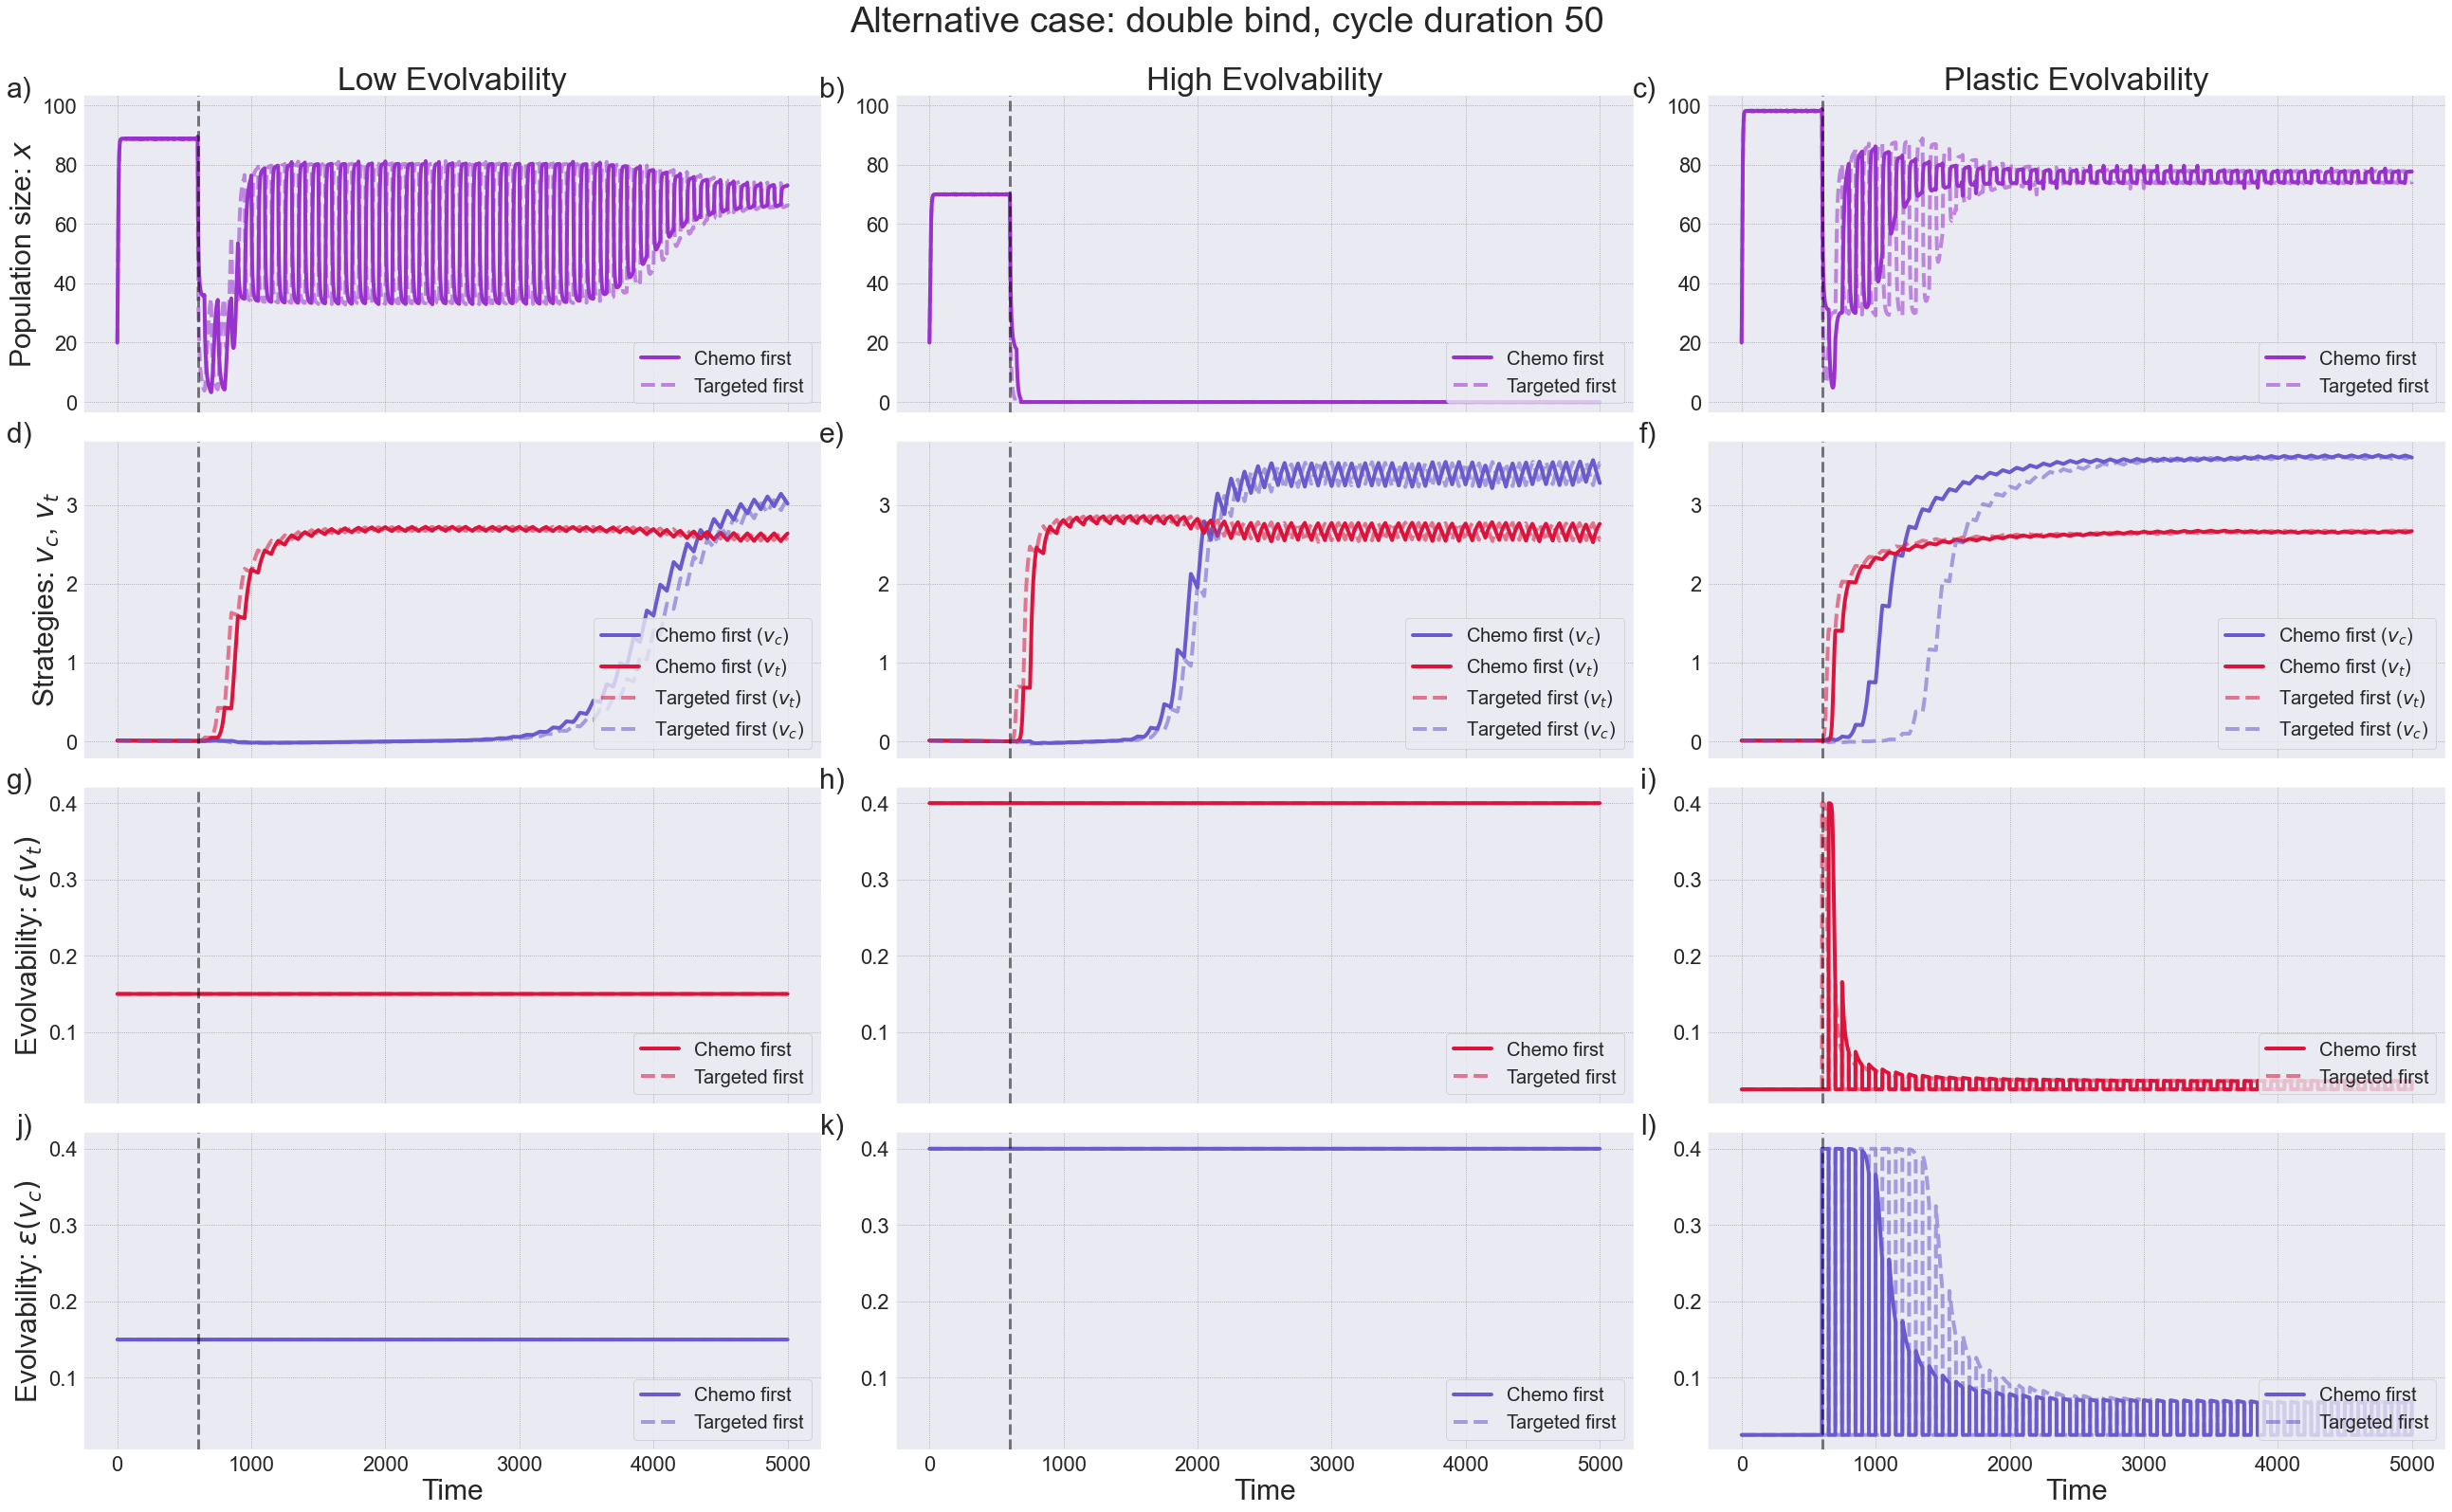

In [74]:
show_alternative_parameters("Figure S3 - double bind", {"cycle duration": 50}, include_facultative_scaling=True)

s3_models = make_double_bind_models(cycle_duration=50)
figure_s3 = plot_double_bind(s3_models, "S3", cycle_duration=50)


## Figure S4 - double bind, cycle duration 300


Alternative case: Figure S4 - double bind


,Parameter,Value
0,growth rate (r),0.320000
1,evolvability cost (d),0.120000
2,maximum carrying capacity (K_m),100.000000
3,carrying-capacity breadth (sigma_k),10.000000
4,baseline evolvability (m),0.025000
5,low fixed evolvability,0.150000
6,high/plastic evolvability ceiling,0.400000
7,chemotherapy efficacy (s_c),0.170000
8,chemotherapy breadth (sigma_sc),2.449490
9,targeted efficacy (s_t),0.300000


Saved Figure_S4.png and Figure_S4.pdf


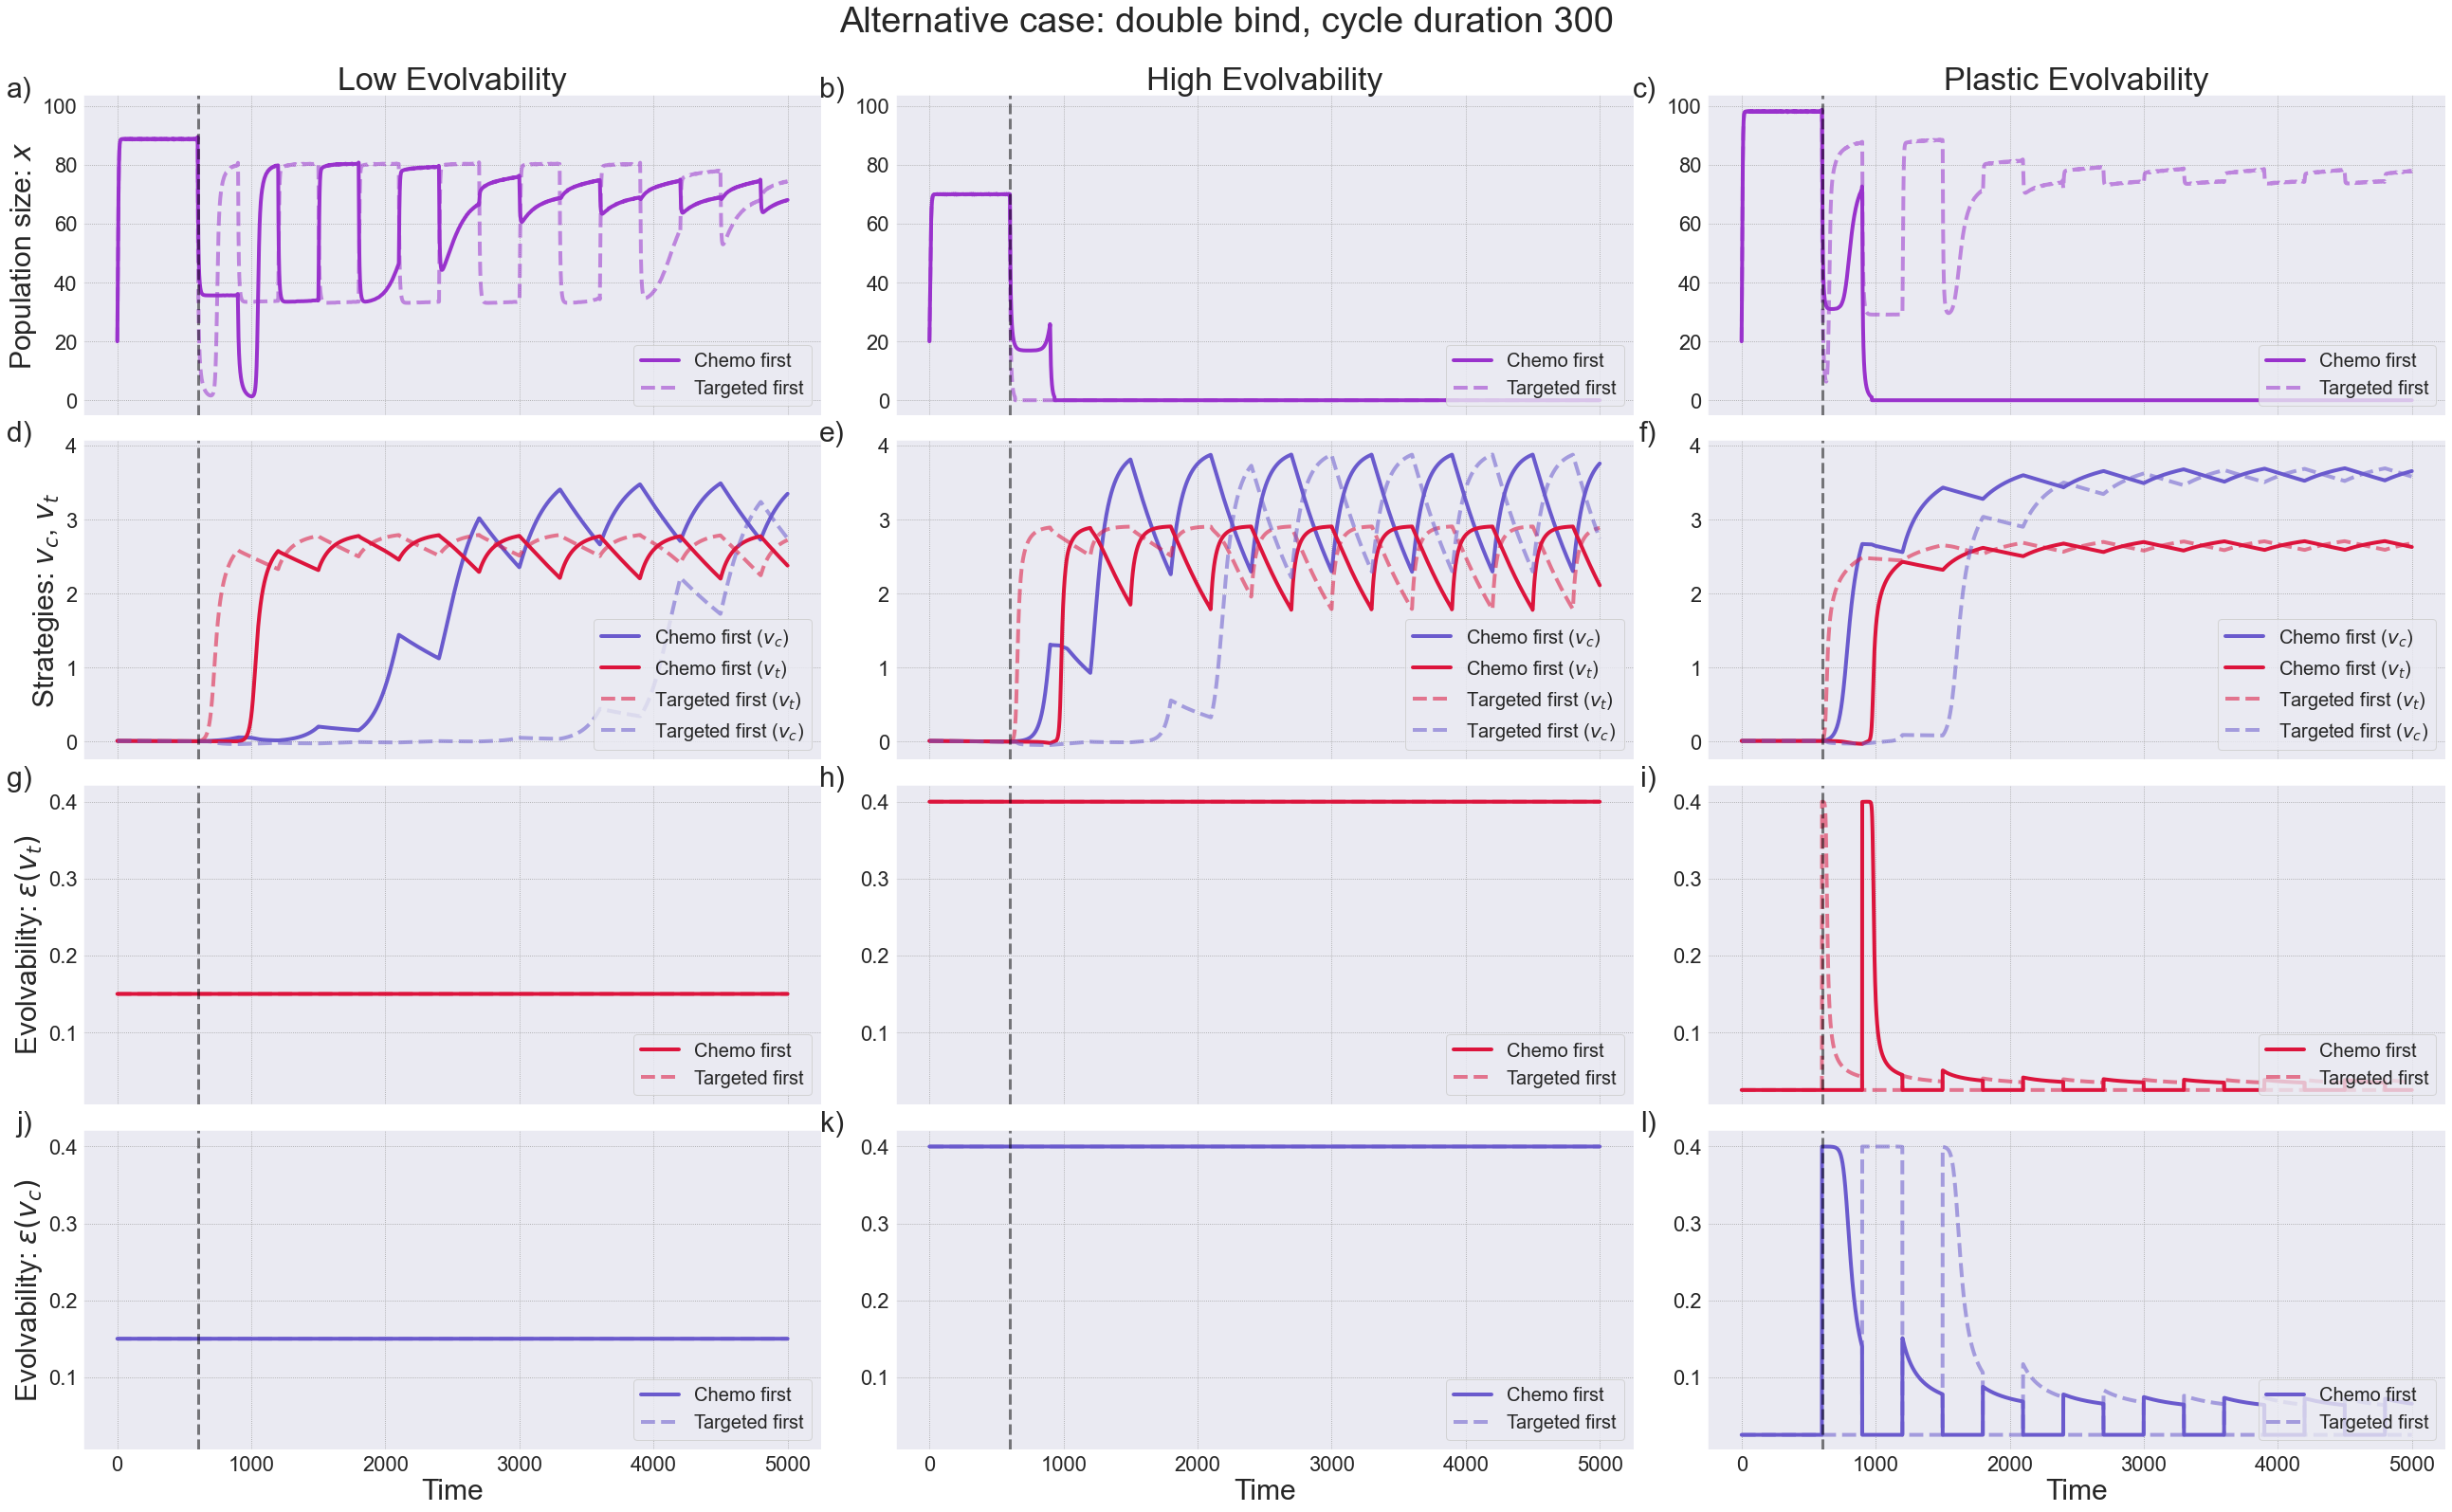

In [77]:
show_alternative_parameters("Figure S4 - double bind", {"cycle duration": 300}, include_facultative_scaling=True)

s4_models = make_double_bind_models(cycle_duration=300)
figure_s4 = plot_double_bind(s4_models, "S4", cycle_duration=300)


## Figure S5 - combination therapy


Alternative case: Figure S5 - combination therapy


,Parameter,Value
0,growth rate (r),0.32
1,evolvability cost (d),0.12
2,maximum carrying capacity (K_m),100
3,carrying-capacity breadth (sigma_k),10
4,baseline evolvability (m),0.025
5,low fixed evolvability,0.15
6,high/plastic evolvability ceiling,0.4
7,chemotherapy efficacy (s_c),0.17
8,chemotherapy breadth (sigma_sc),2.44949
9,targeted efficacy (s_t),0.3


Saved Figure_S5.png and Figure_S5.pdf


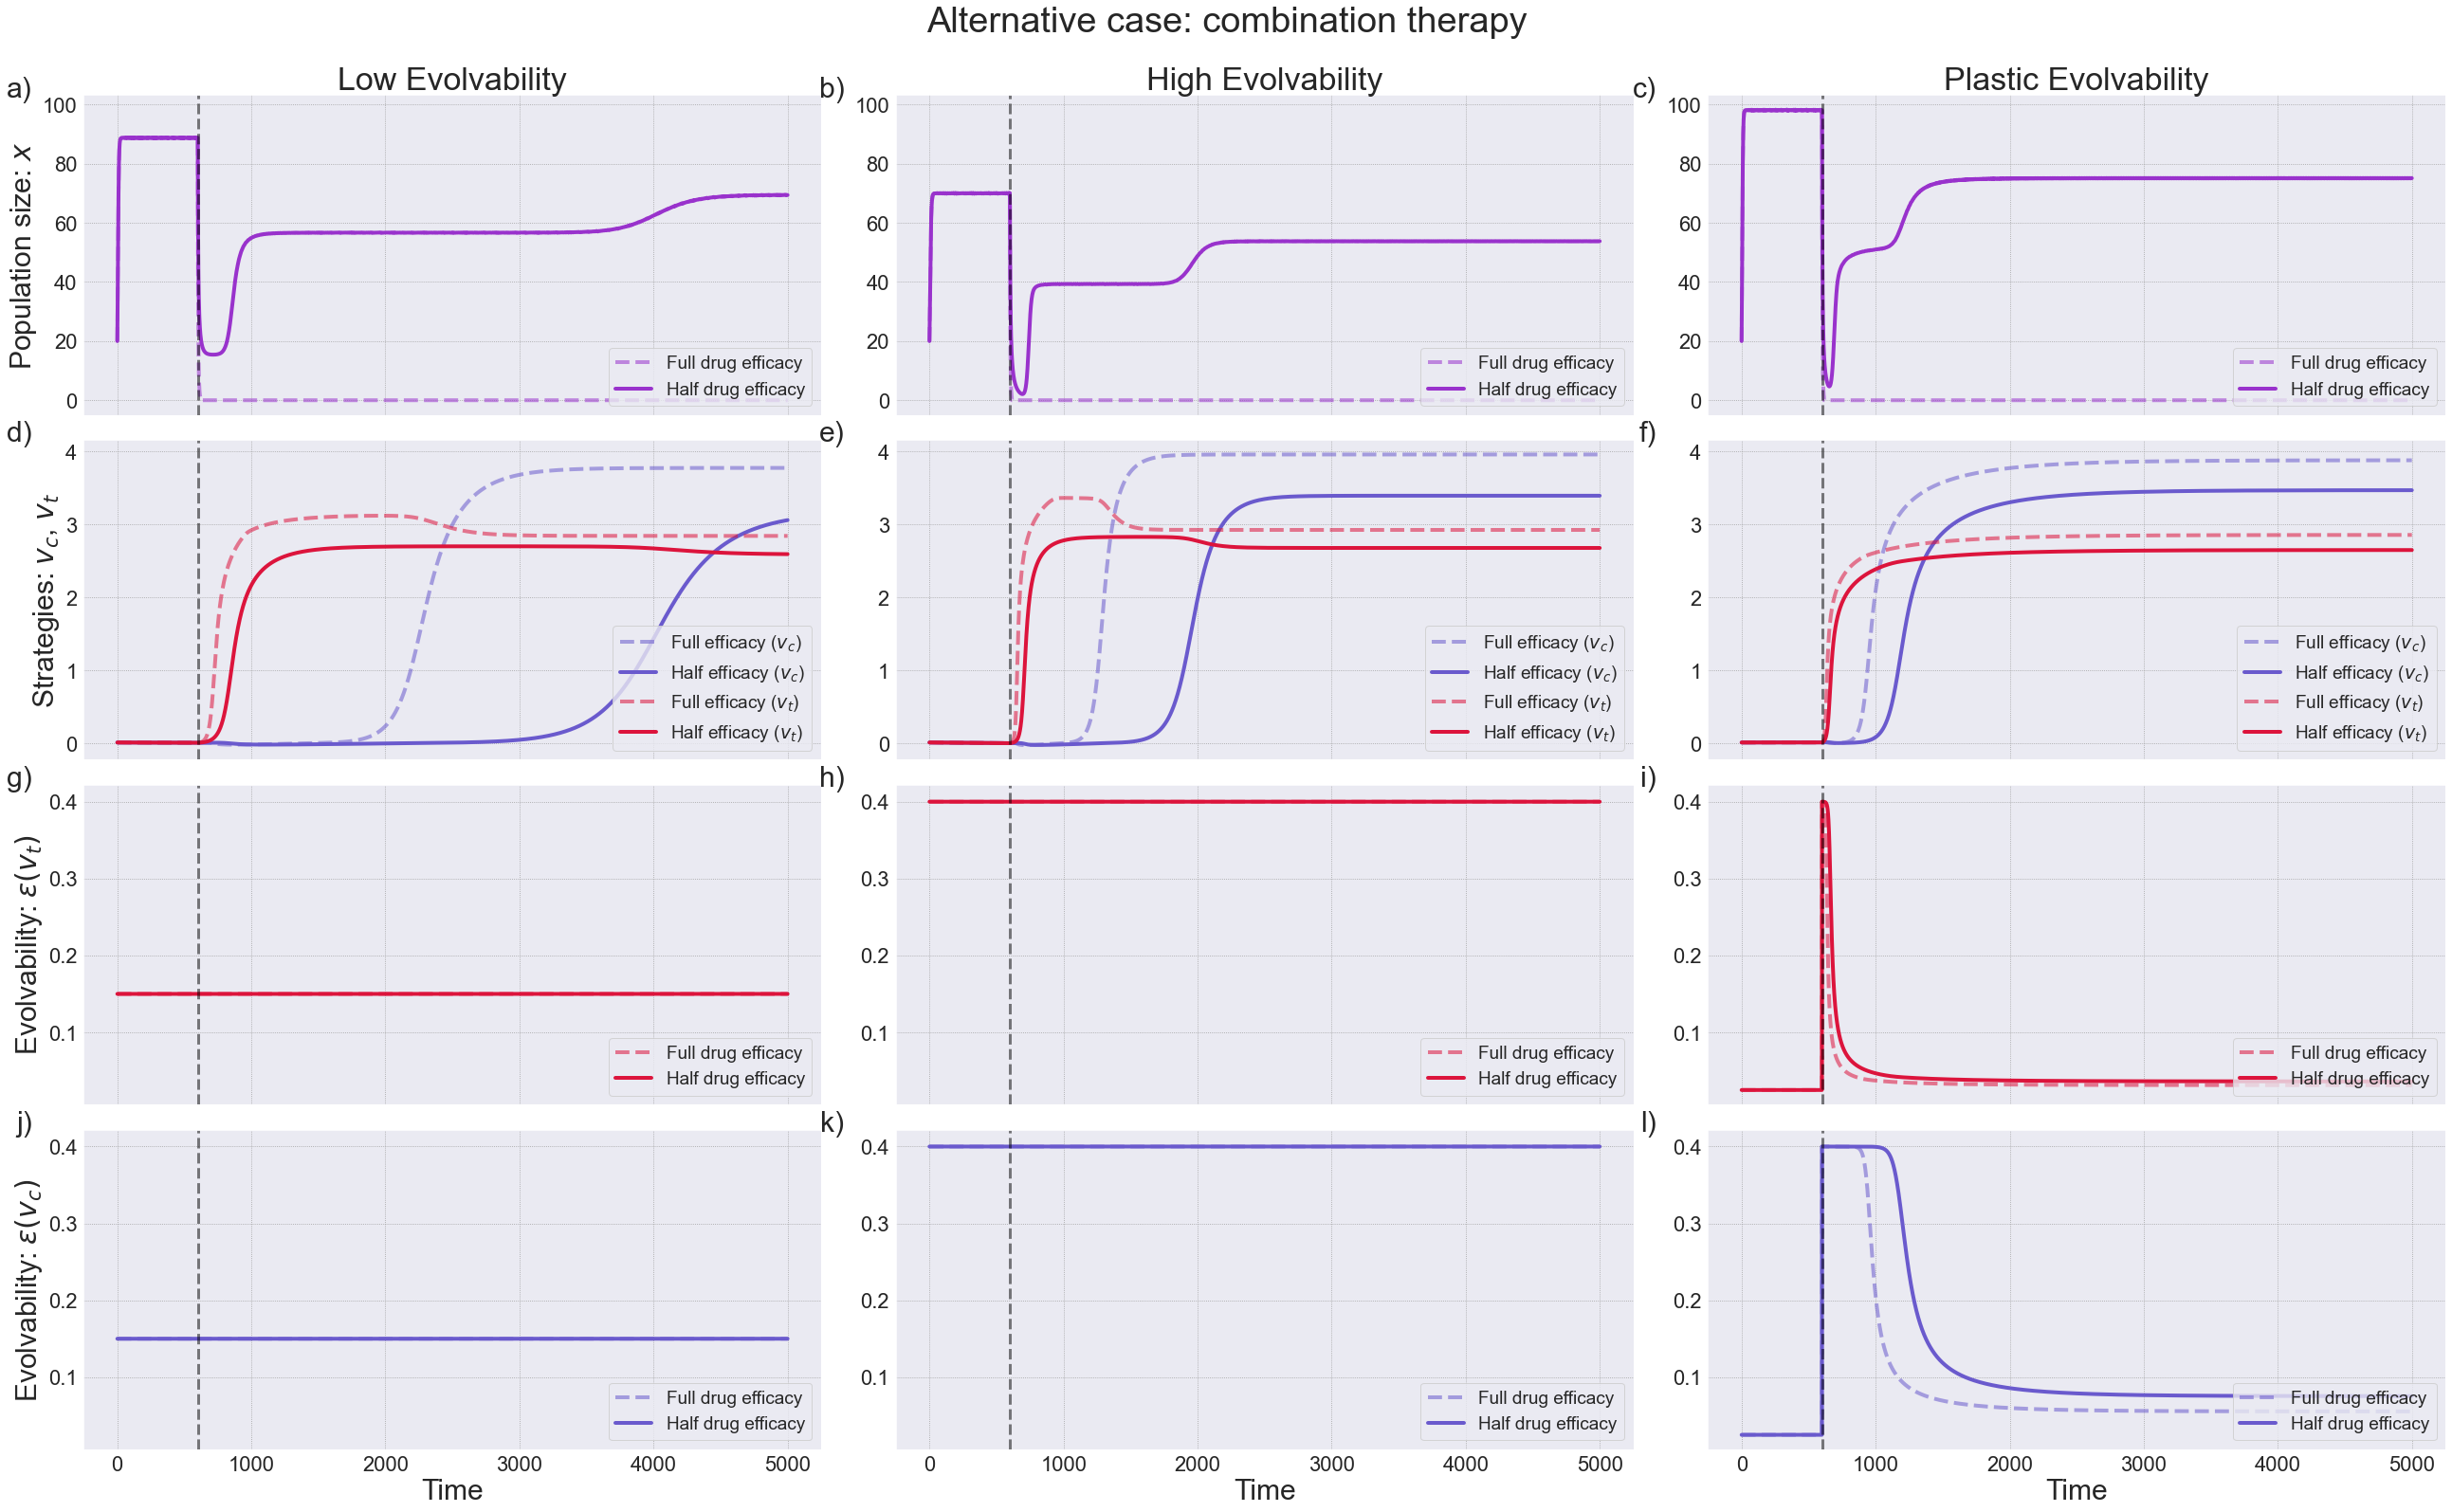

In [79]:
show_alternative_parameters("Figure S5 - combination therapy", {"dose levels": "full and half"}, include_facultative_scaling=True, include_half_dose_scaling=True)

s5_models = make_combination_models()
figure_s5 = plot_combination(s5_models)


## Figure S6 - double bind, cycle duration 500


Alternative case: Figure S6 - double bind


,Parameter,Value
0,growth rate (r),0.320000
1,evolvability cost (d),0.120000
2,maximum carrying capacity (K_m),100.000000
3,carrying-capacity breadth (sigma_k),10.000000
4,baseline evolvability (m),0.025000
5,low fixed evolvability,0.150000
6,high/plastic evolvability ceiling,0.400000
7,chemotherapy efficacy (s_c),0.170000
8,chemotherapy breadth (sigma_sc),2.449490
9,targeted efficacy (s_t),0.300000


Saved Figure_S6.png and Figure_S6.pdf


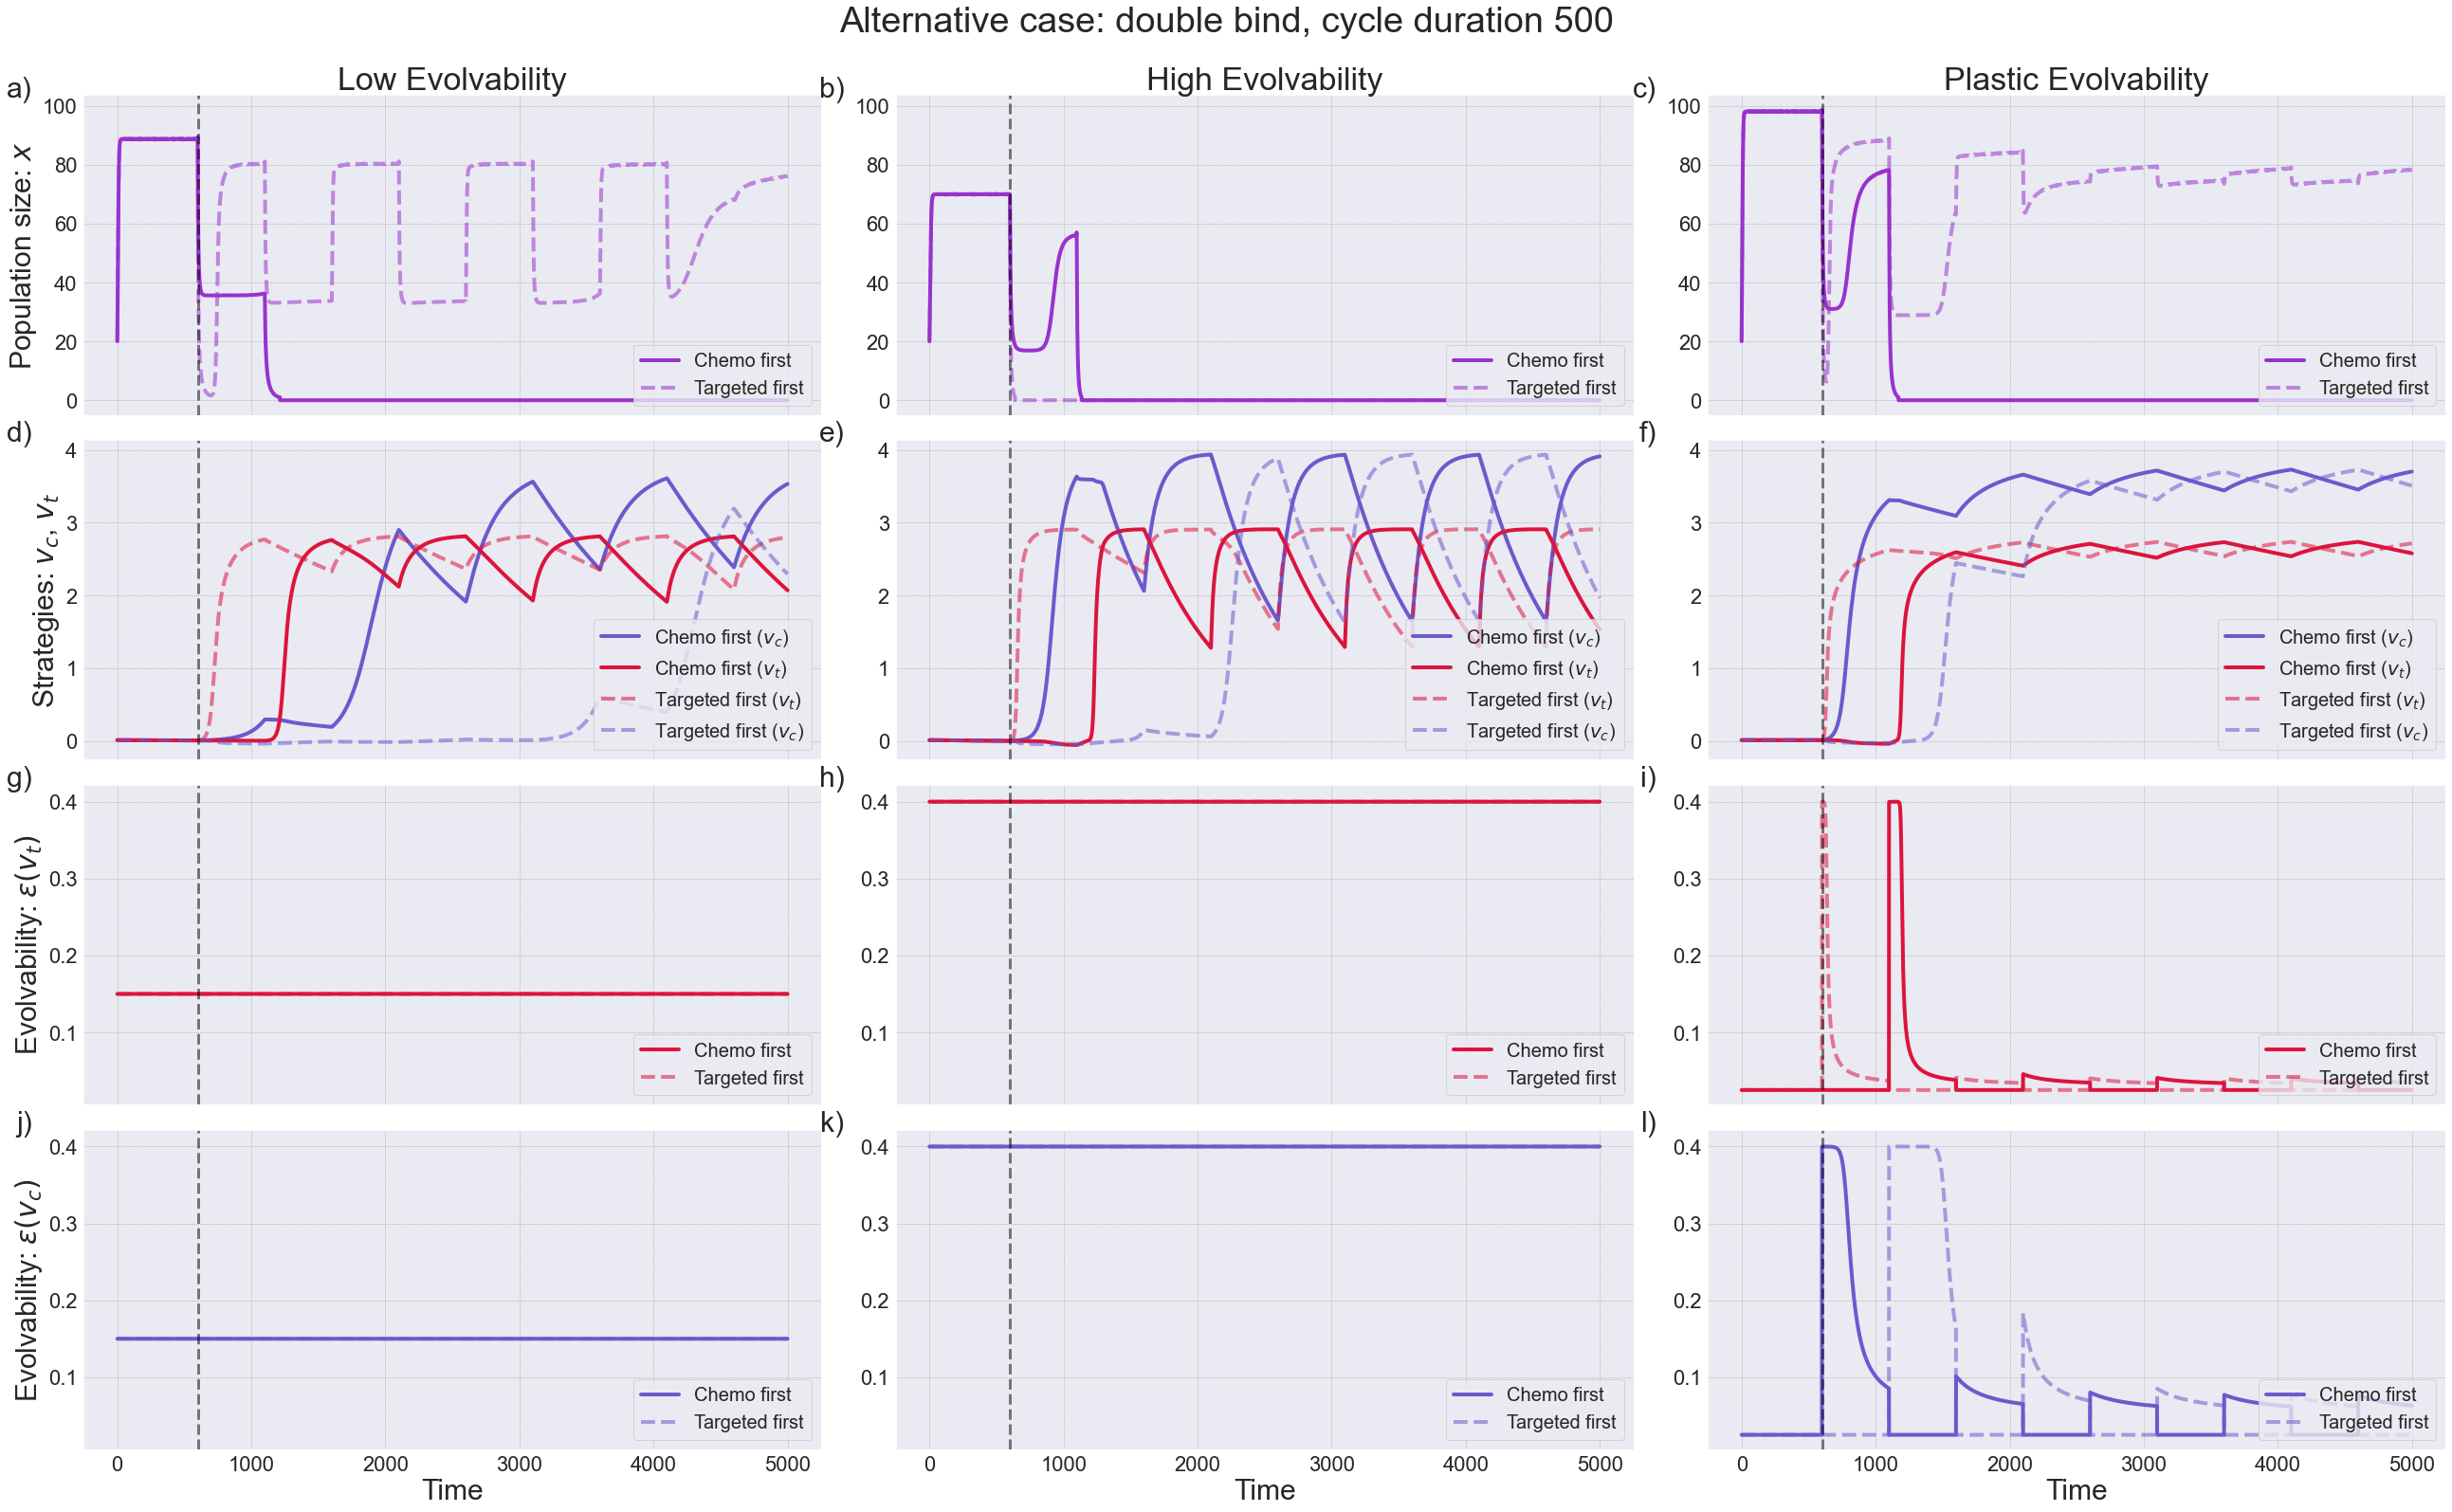

In [80]:
show_alternative_parameters("Figure S6 - double bind", {"cycle duration": 500}, include_facultative_scaling=True)

s6_models = make_double_bind_models(cycle_duration=500)
figure_s6 = plot_double_bind(s6_models, "S6", cycle_duration=500)


## Extinction summary


In [28]:
summary_rows = []

for figure, models in [("S3", s3_models), ("S4", s4_models), ("S6", s6_models)]:
    for population, chemo_first, targeted_first in models:
        summary_rows.extend(
            [
                {
                    "figure": figure,
                    "population": population,
                    "regimen": "Chemo first",
                    "extinction_time": extinction_time(chemo_first),
                    "final_population": chemo_first.y[0, -1],
                },
                {
                    "figure": figure,
                    "population": population,
                    "regimen": "Targeted first",
                    "extinction_time": extinction_time(targeted_first),
                    "final_population": targeted_first.y[0, -1],
                },
            ]
        )

for population, full, half in s5_models:
    summary_rows.extend(
        [
            {
                "figure": "S5",
                "population": population,
                "regimen": "Full efficacy",
                "extinction_time": extinction_time(full),
                "final_population": full.y[0, -1],
            },
            {
                "figure": "S5",
                "population": population,
                "regimen": "Half efficacy",
                "extinction_time": extinction_time(half),
                "final_population": half.y[0, -1],
            },
        ]
    )

summary = pd.DataFrame(summary_rows)
summary.to_csv(OUTPUT_DIR / "S3_S6_extinction_summary.csv", index=False)
summary


,figure,population,regimen,extinction_time,final_population
0,S3,Low Evolvability,Chemo first,NaN,72.950351
1,S3,Low Evolvability,Targeted first,NaN,66.806713
2,S3,High Evolvability,Chemo first,682.0,0.000000
3,S3,High Evolvability,Targeted first,639.0,0.000000
4,S3,Plastic Evolvability,Chemo first,NaN,77.630236
5,S3,Plastic Evolvability,Targeted first,NaN,74.195692
6,S4,Low Evolvability,Chemo first,NaN,68.064942
7,S4,Low Evolvability,Targeted first,NaN,74.394257
8,S4,High Evolvability,Chemo first,934.0,0.000000
9,S4,High Evolvability,Targeted first,639.0,0.000000
